In [4]:
import pandas as pd
import importlib
import data_audit

importlib.reload(data_audit)


df = pd.read_csv("lifestyle_in_different_towns.csv")


# city_name: Идентификатор на града.
# country: Географски регион.
# population_density: Население на квадратен километър.
# avg_income: Среден месечен доход на домакинство в долари.
# internet_penetration: Процент на домакинства, които имат достъп до Интернет.
# avg_rent: Среден месечен наем на апартамент в долари.
# air_quality_index: Индекс на качеството на въздуха, където по-ниски стойности съответстват на по-чист въздух.
# public_transport_score: Качество на обществения транспорт, където по-високи стойности съответстват на по-висока оценка.
# happiness_score: Удовлетвореност от живота, получена след допитване до случайни граждани, където по-високи стойности съответстват на по-висока оценка.
# green_space_ratio: Процент на градската площ, покрита с паркове/зелени пространства.


Created correlation heatmap
Saved column data to Excel
Created histograms and bar charts for column city_name
Saved column data to Excel
Created histograms and bar charts for column country
Saved column data to Excel
Created histograms and bar charts for column population_density
Saved column data to Excel
Created histograms and bar charts for column avg_income
Saved column data to Excel
Created histograms and bar charts for column internet_penetration
Saved column data to Excel
Created histograms and bar charts for column avg_rent
Saved column data to Excel
Created histograms and bar charts for column air_quality_index
Saved column data to Excel
Created histograms and bar charts for column public_transport_score
Saved column data to Excel
Created histograms and bar charts for column happiness_score
Saved column data to Excel
Created histograms and bar charts for column green_space_ratio
Saved correlation heatmap in Excel
Saved pairplot in Excel
Saved column charts in Excel


<Figure size 640x480 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

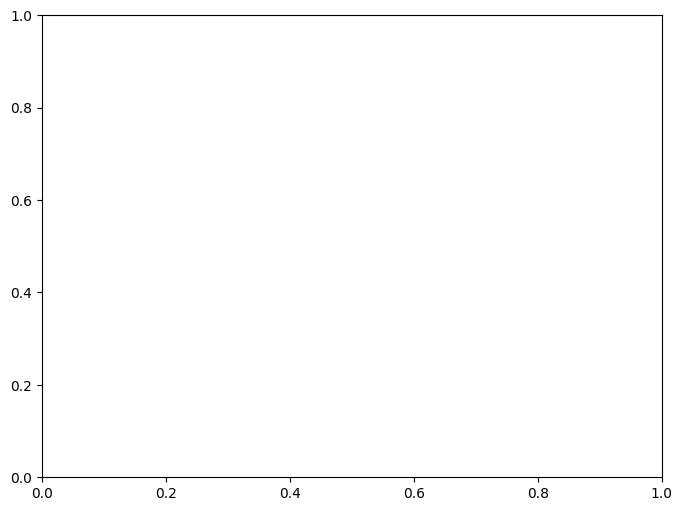

In [5]:
# This if is put so that i can run all 
# cells without creating data audit every time
if True:

    data_audit.create_data_audit(df, bar_chart_cols=['country'], no_chart_cols=[], hue_column=None)

In [6]:
# Preprocessing

df_dummies = pd.get_dummies(df['country'], drop_first=True, dtype=int)
df = pd.concat([df_dummies,df.drop(columns=['country'])], axis=1)

In [7]:
print(df.columns)

Index(['Asia', 'Europe', 'North America', 'Oceania', 'South America',
       'city_name', 'population_density', 'avg_income', 'internet_penetration',
       'avg_rent', 'air_quality_index', 'public_transport_score',
       'happiness_score', 'green_space_ratio'],
      dtype='object')


0.8.41
1.8.0
n_components=array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 13])


/home/bryan/Documents/FMI/ML/Homework2/clusterization.py:232: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 5))


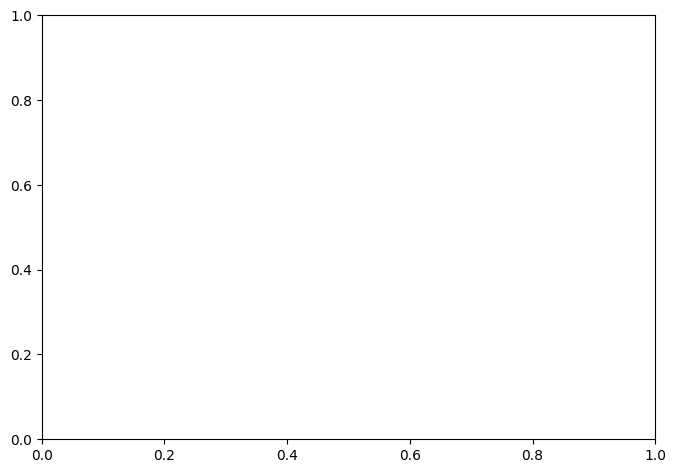

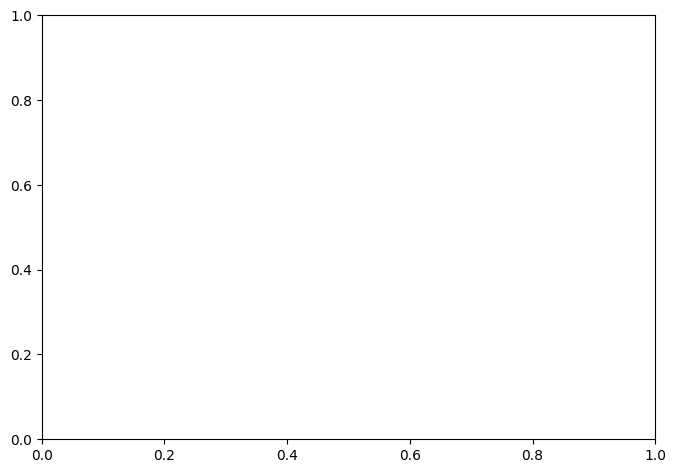

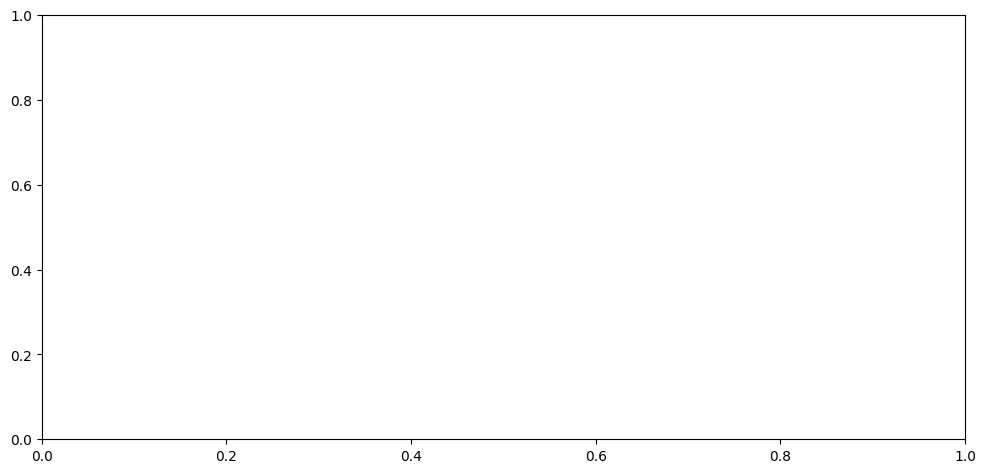

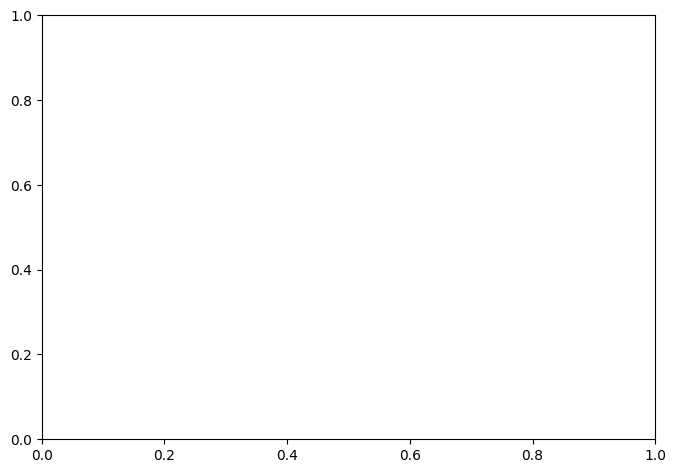

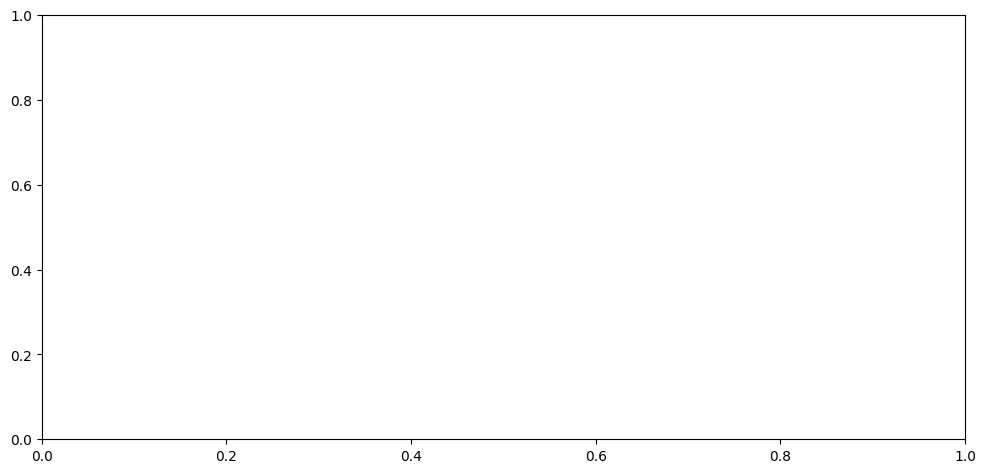

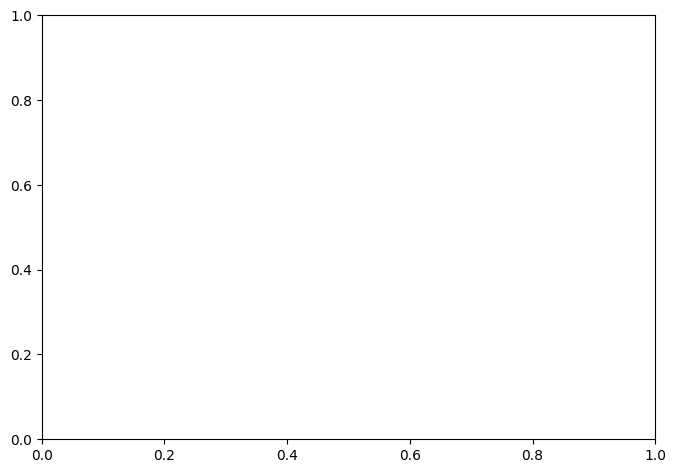

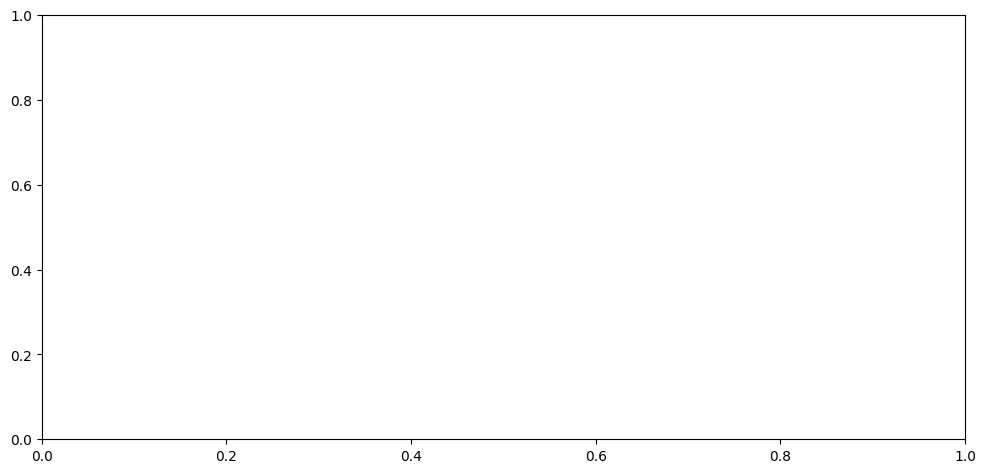

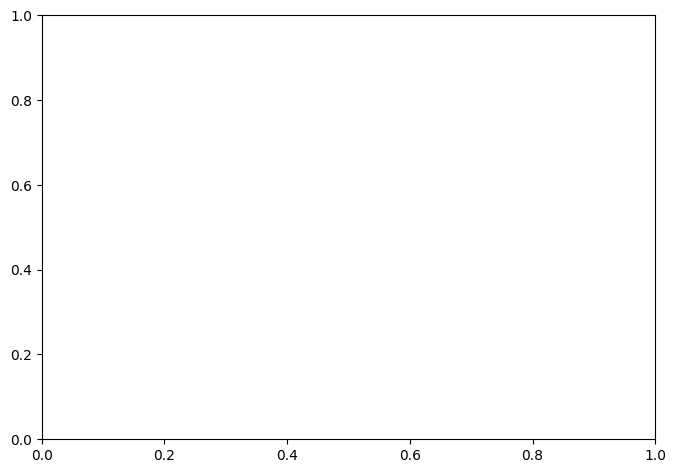

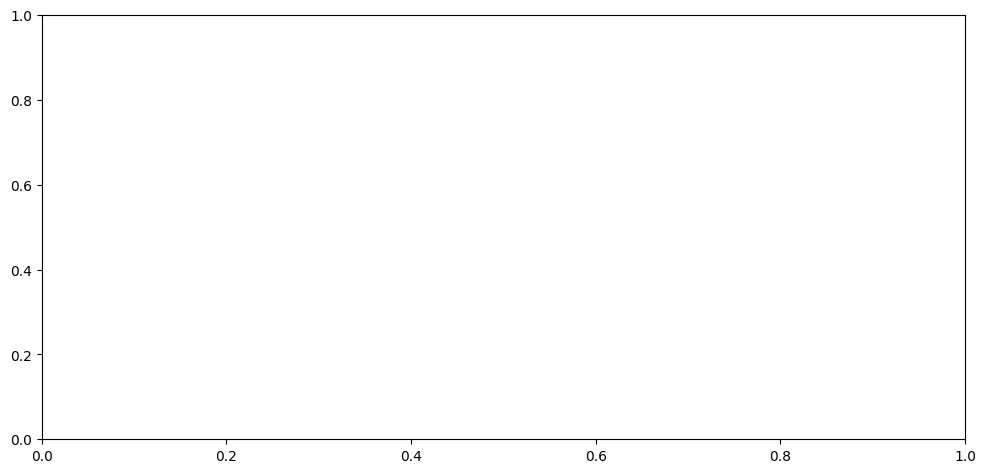

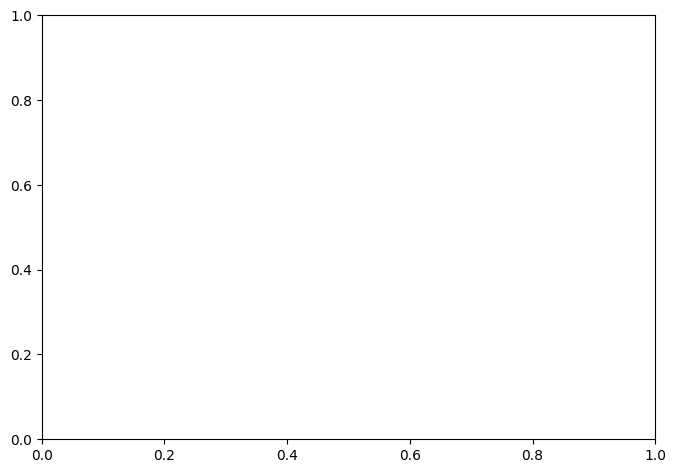

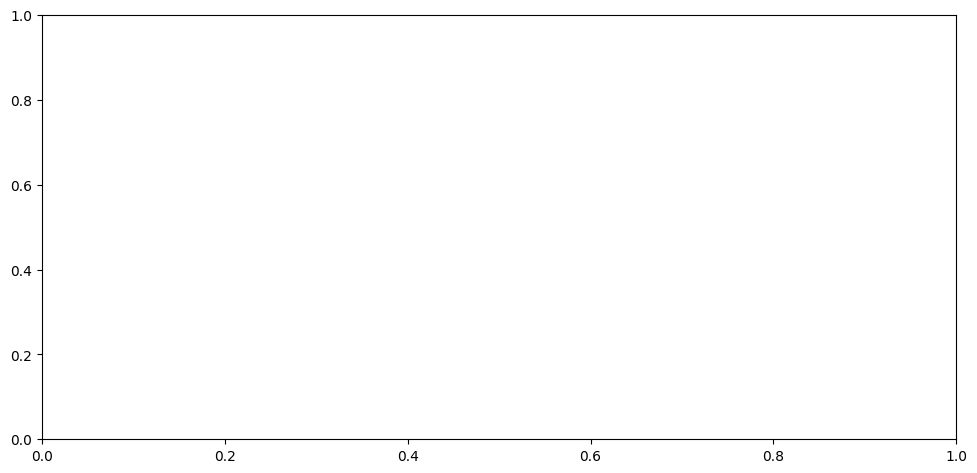

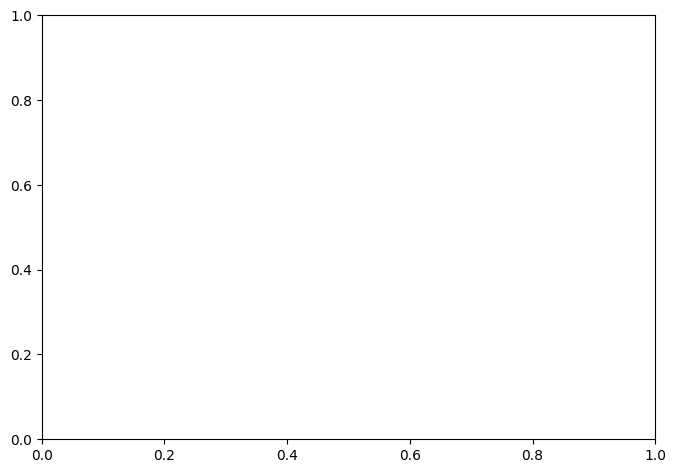

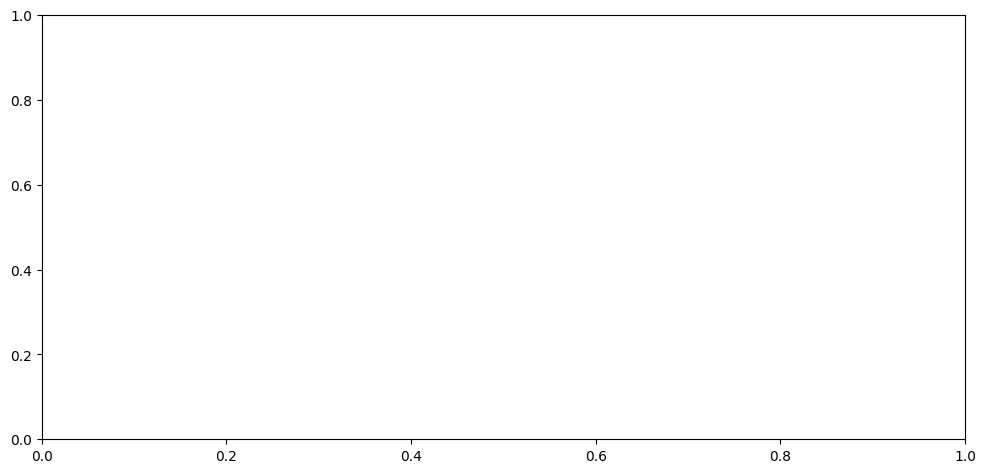

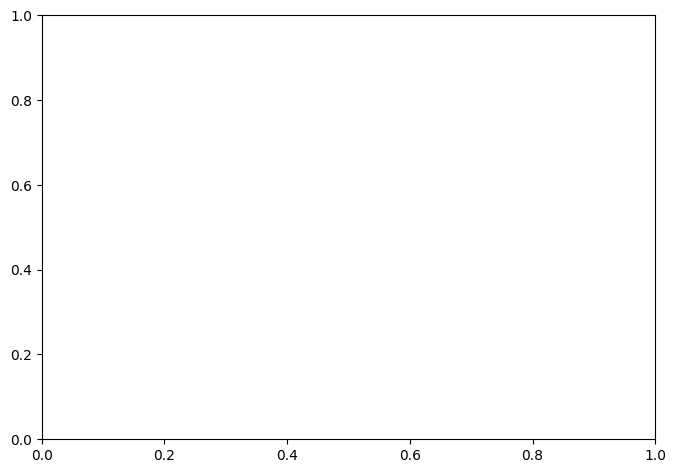

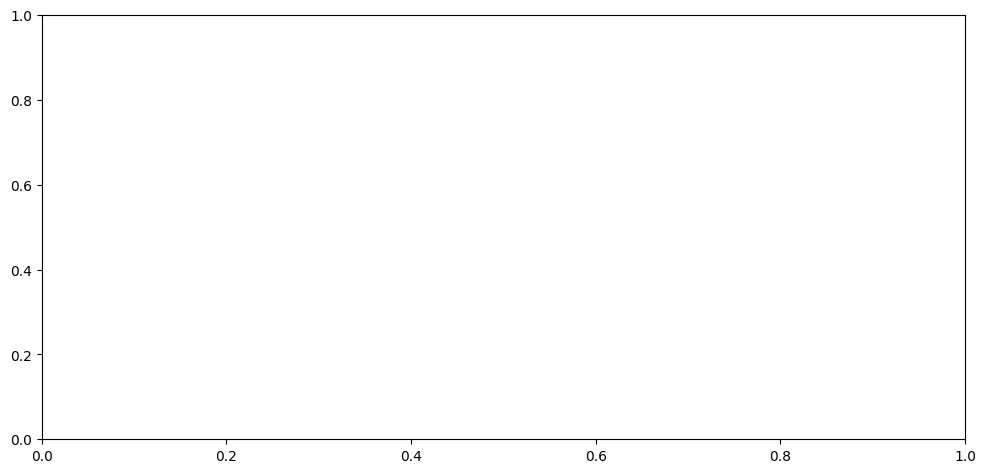

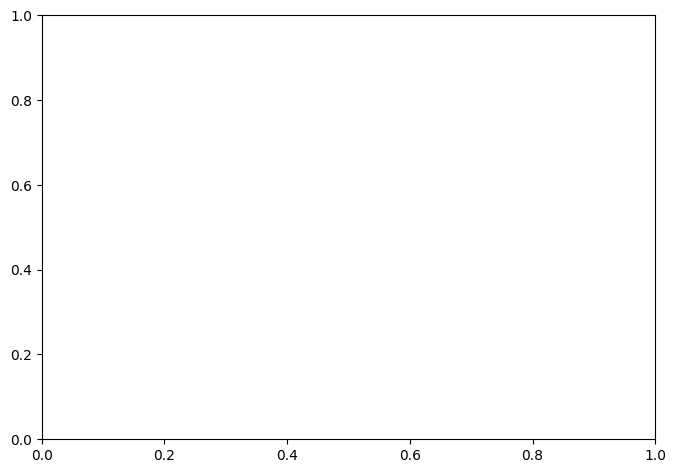

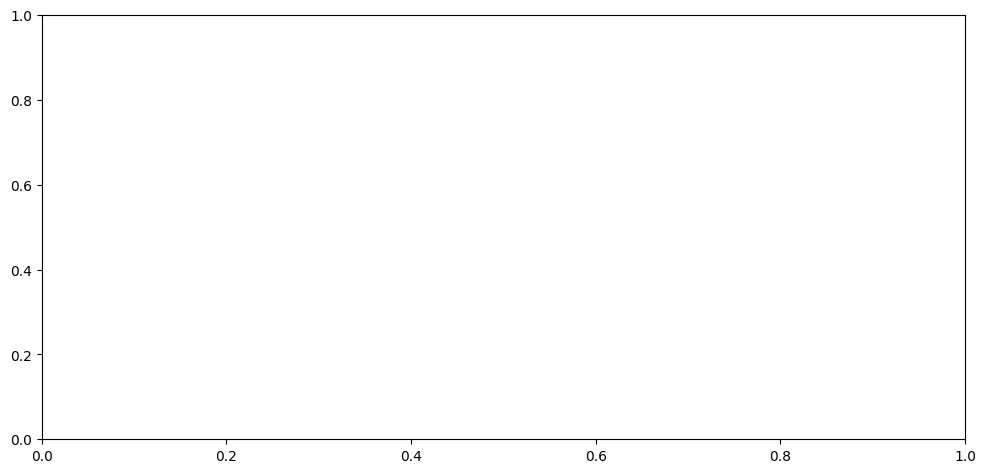

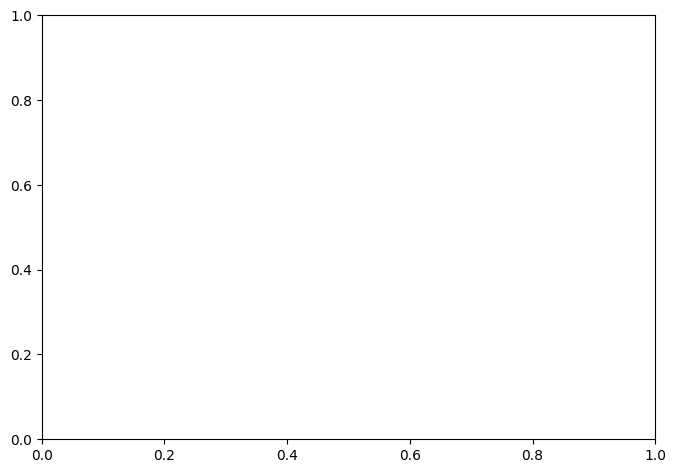

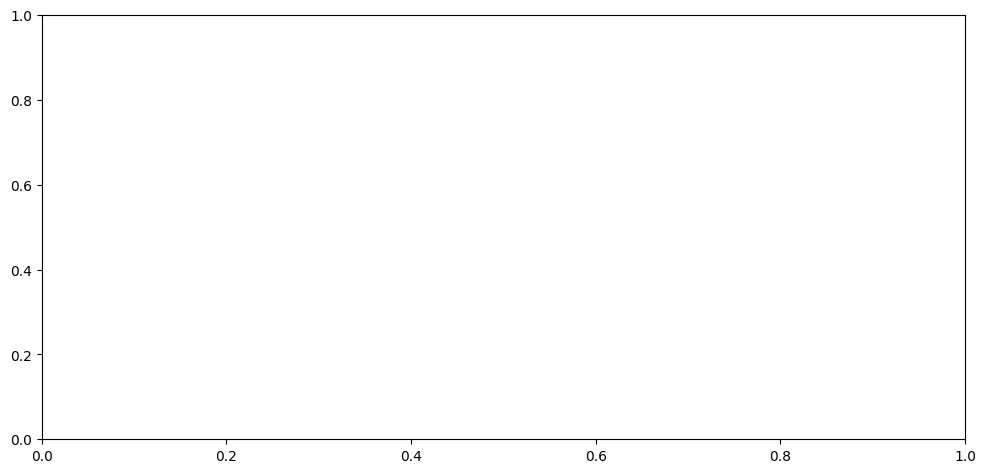

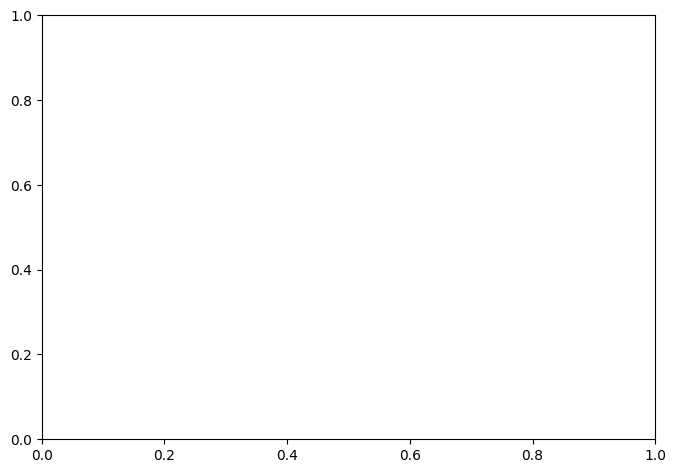

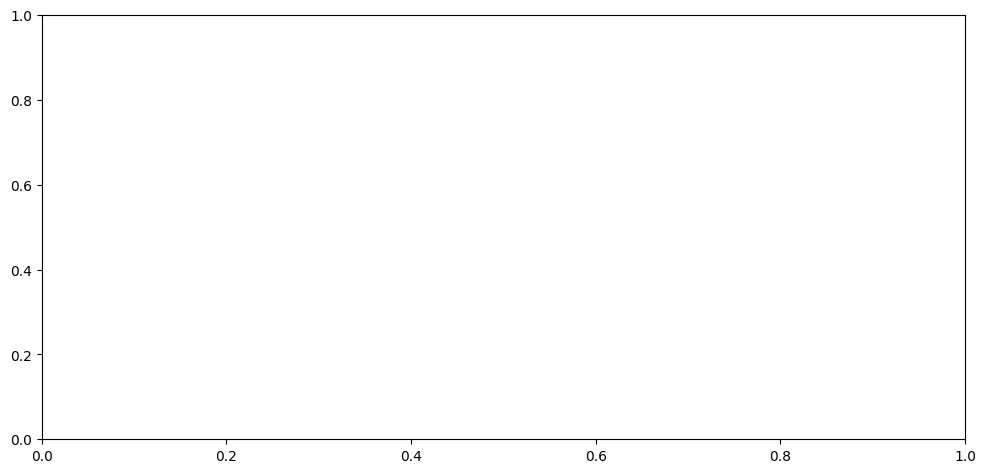

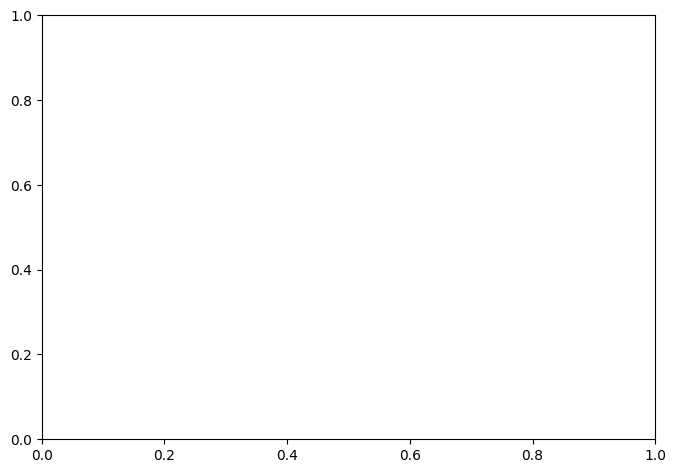

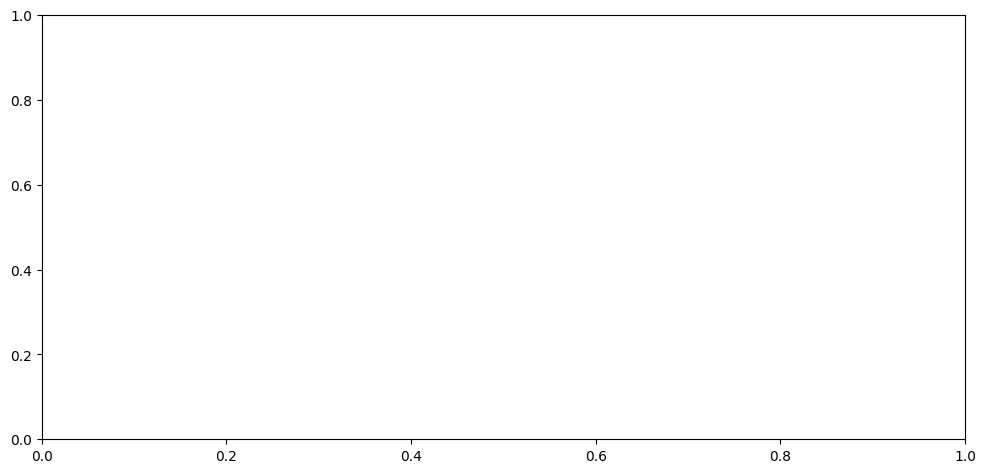

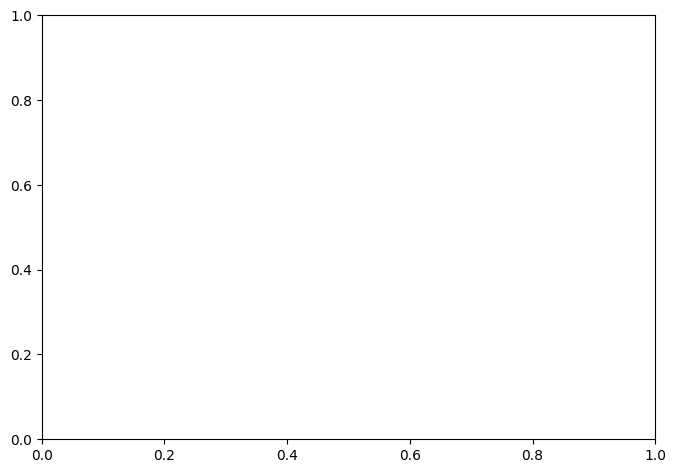

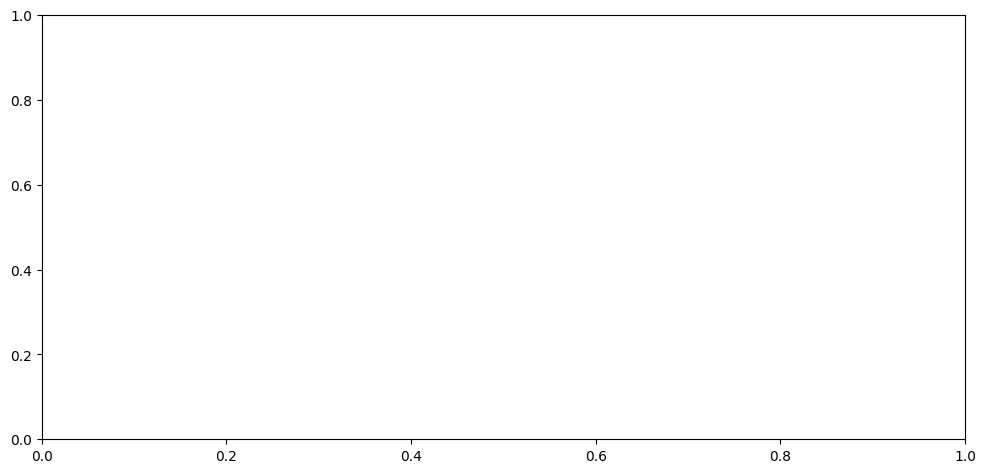

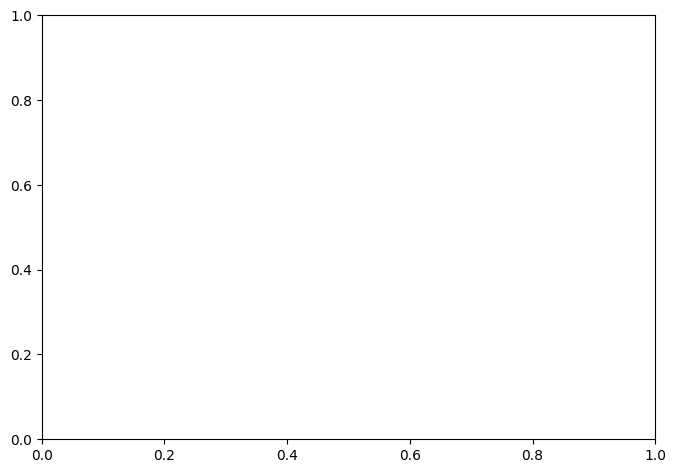

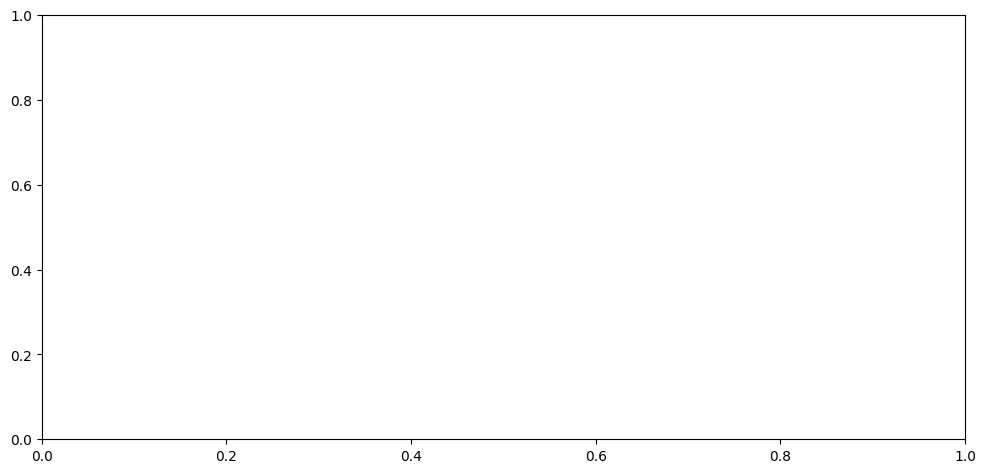

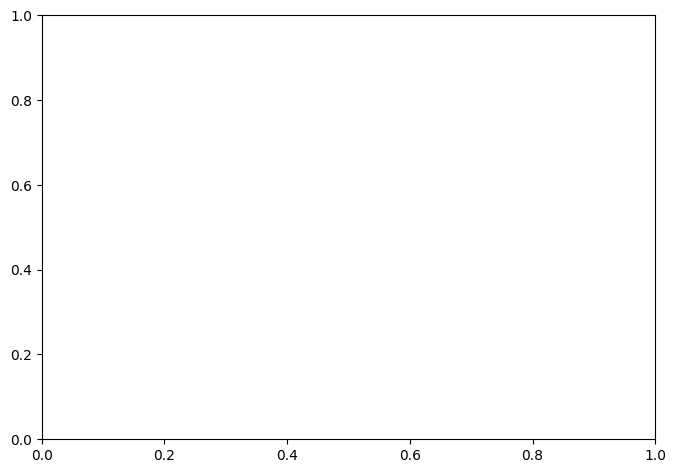

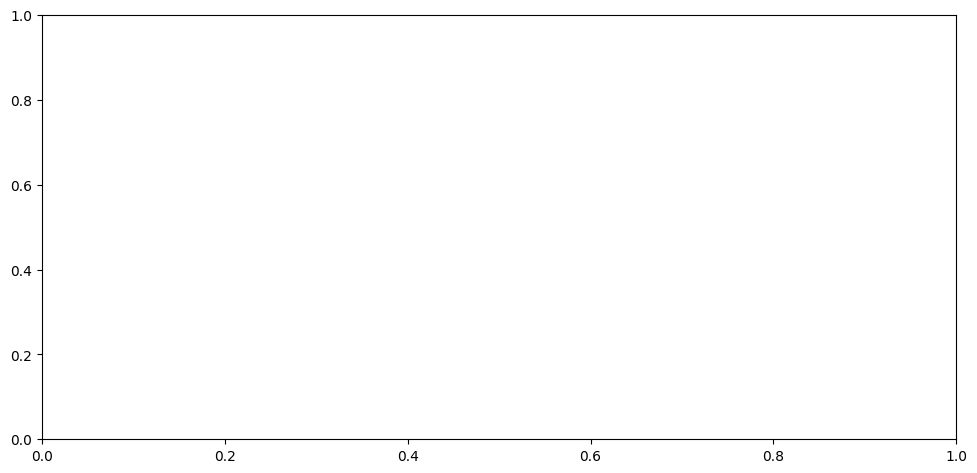

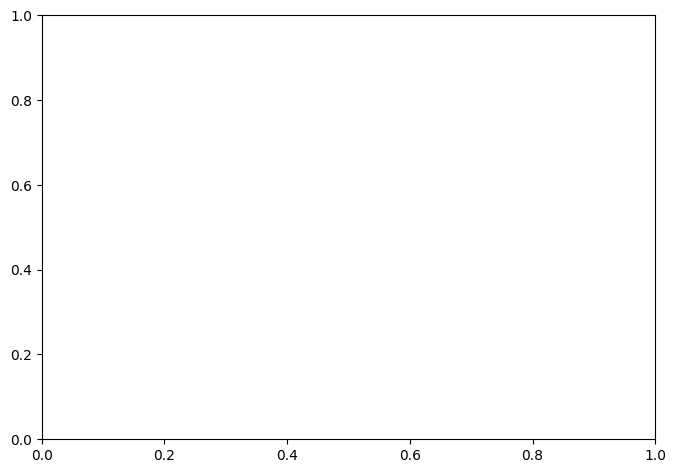

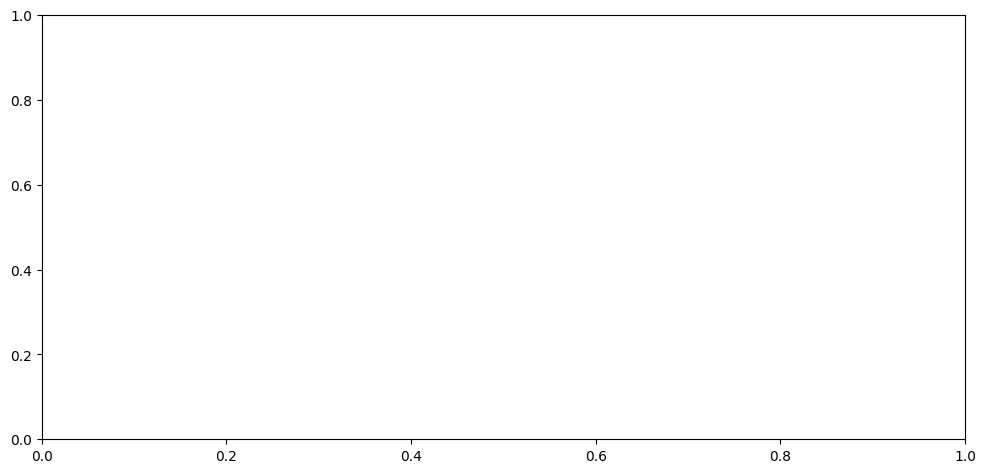

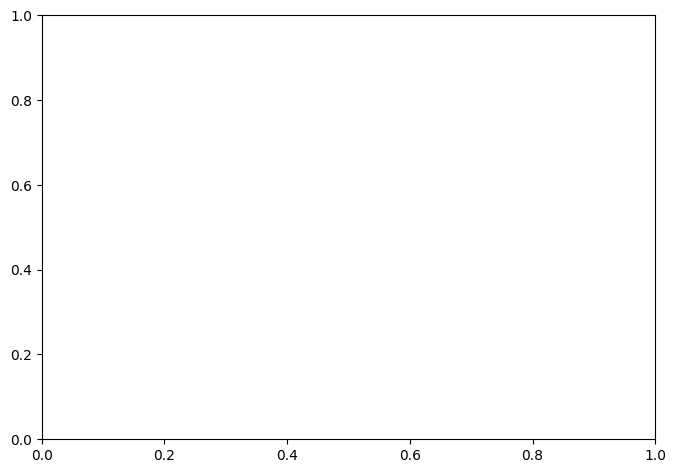

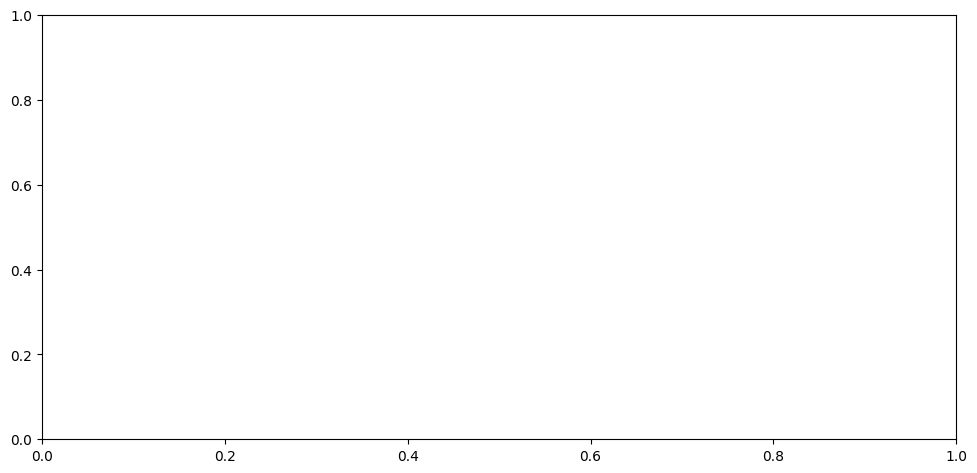

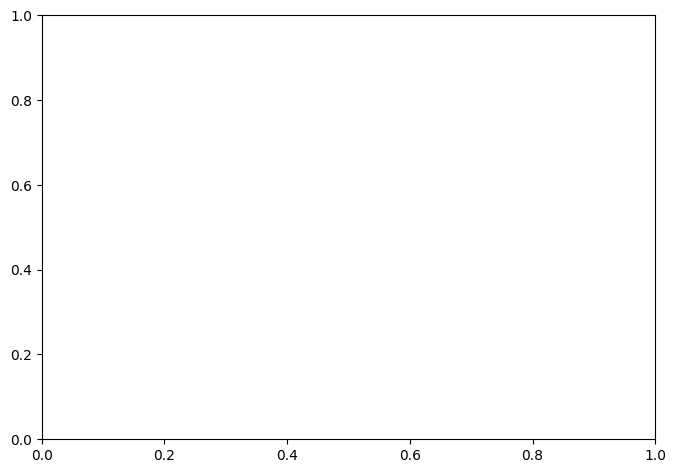

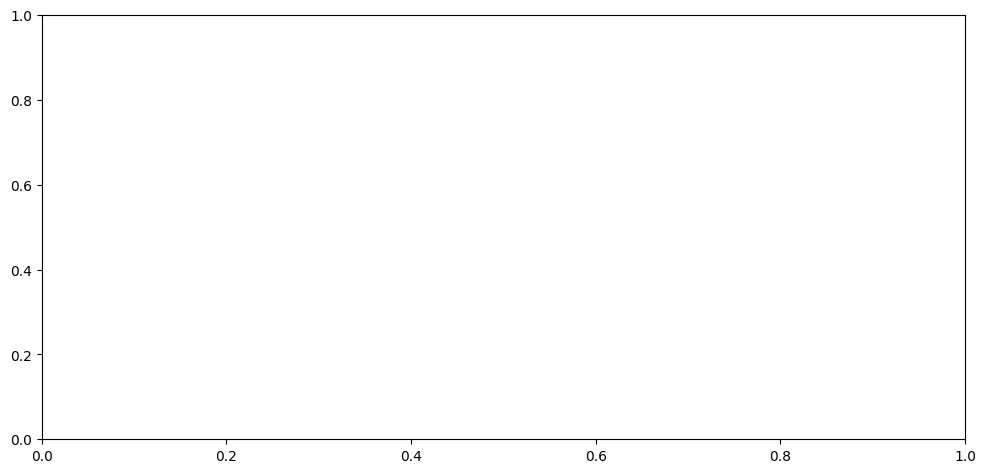

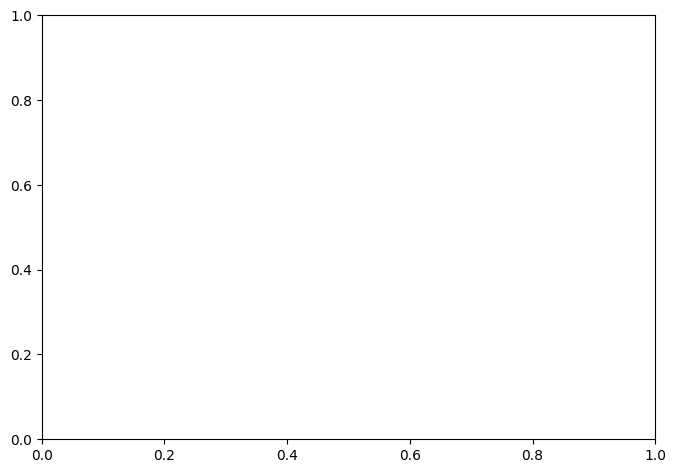

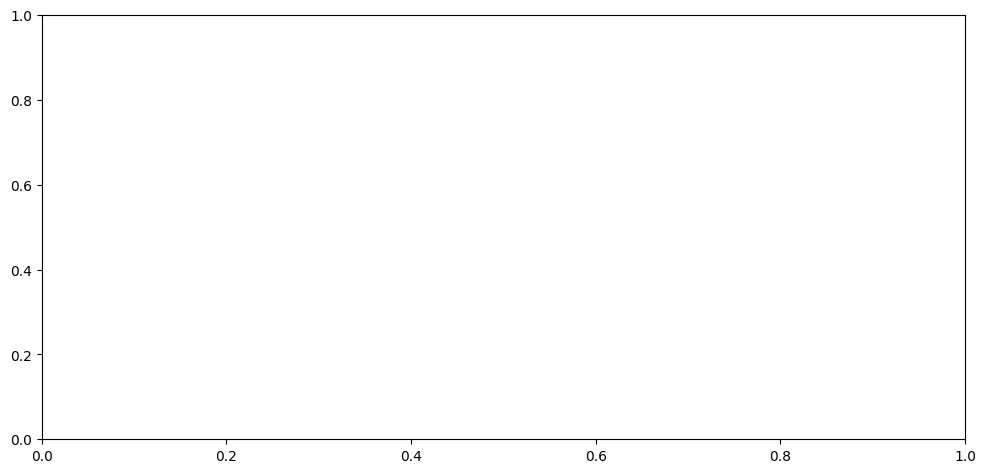

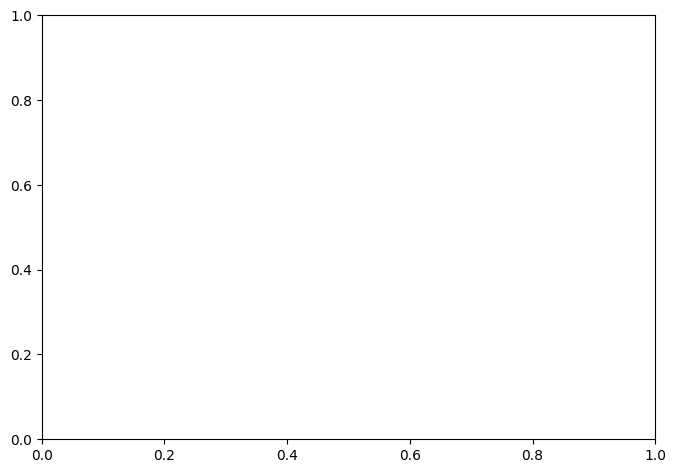

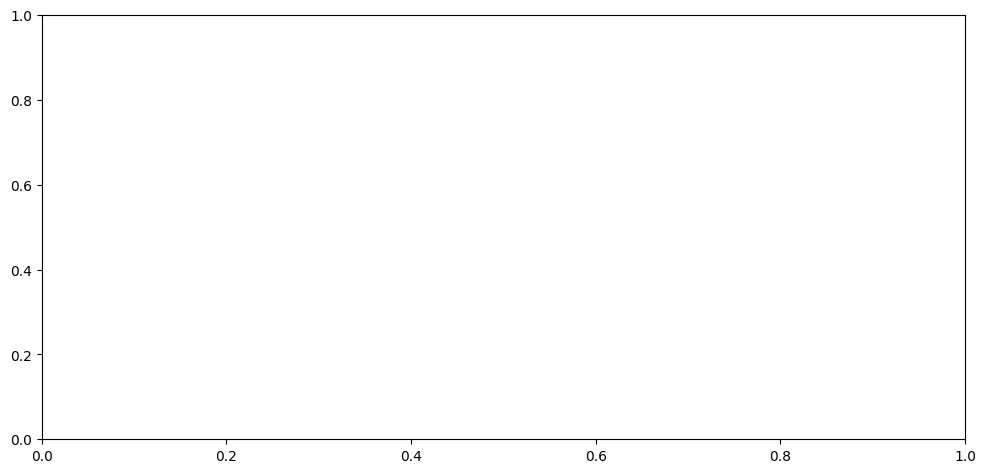

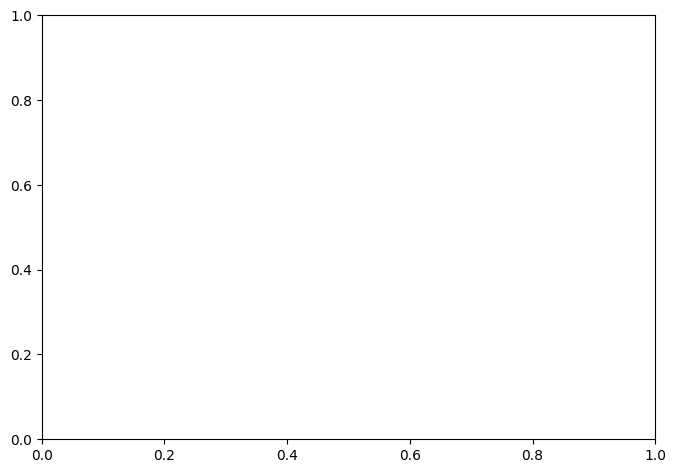

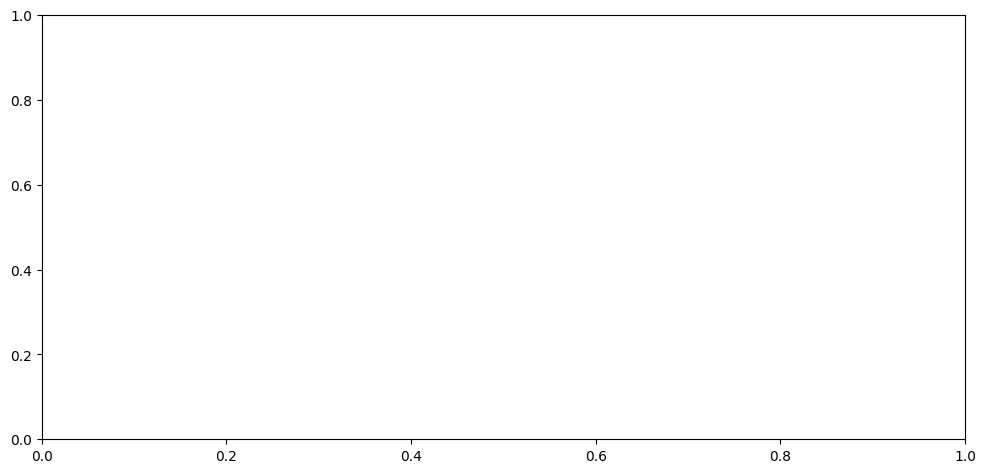

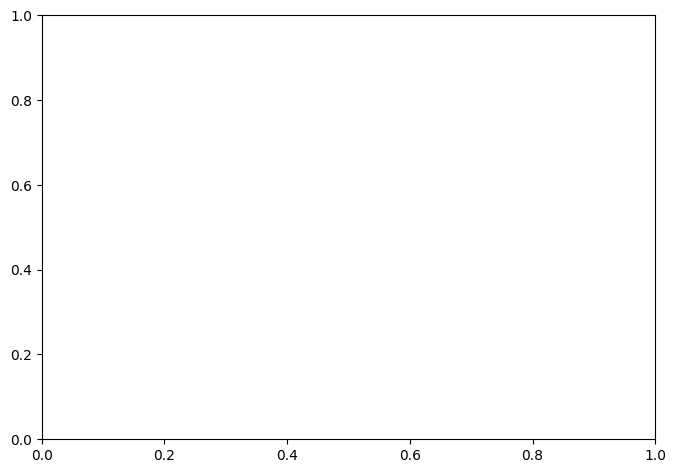

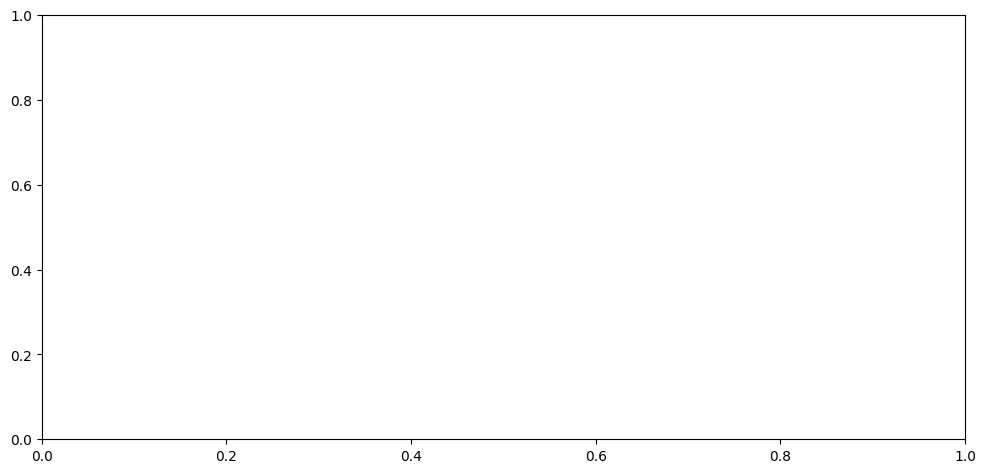

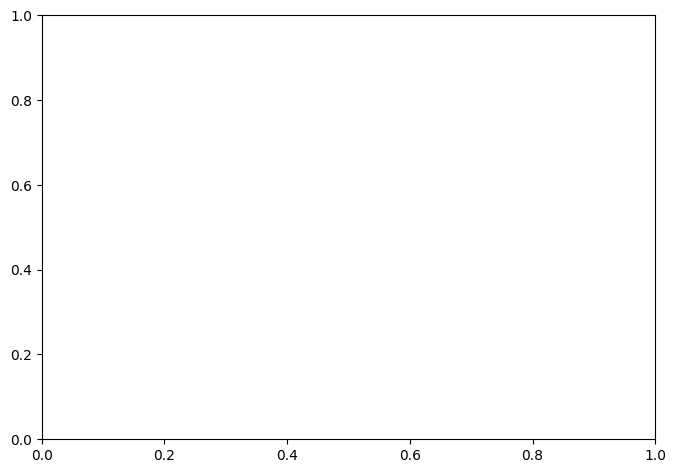

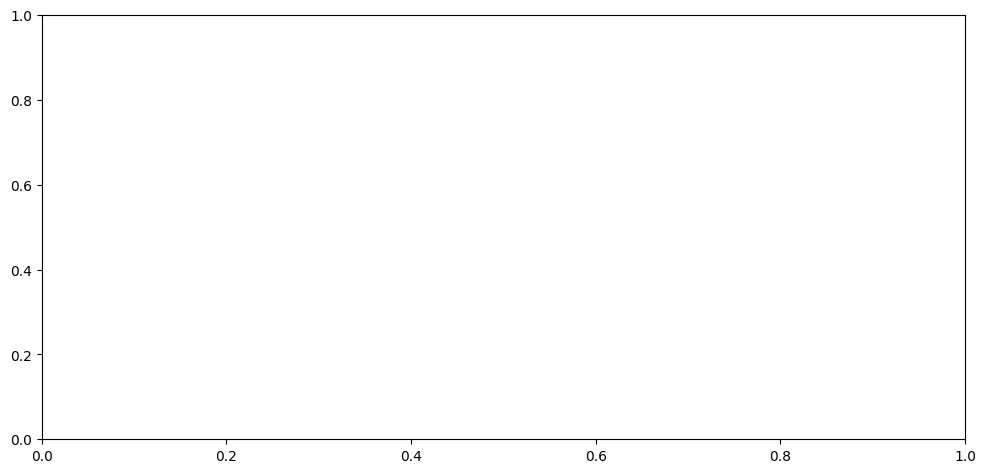

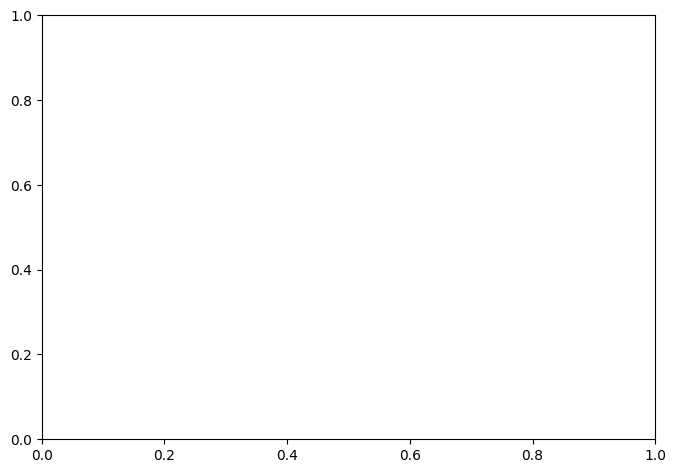

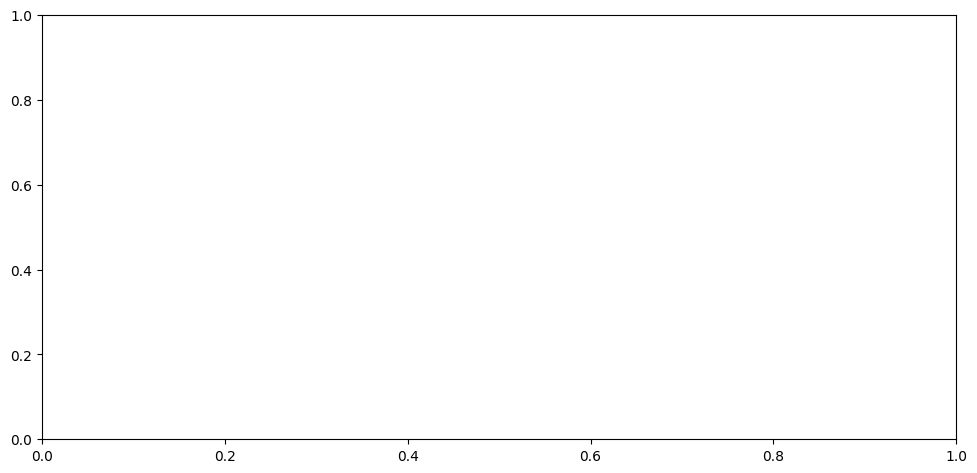

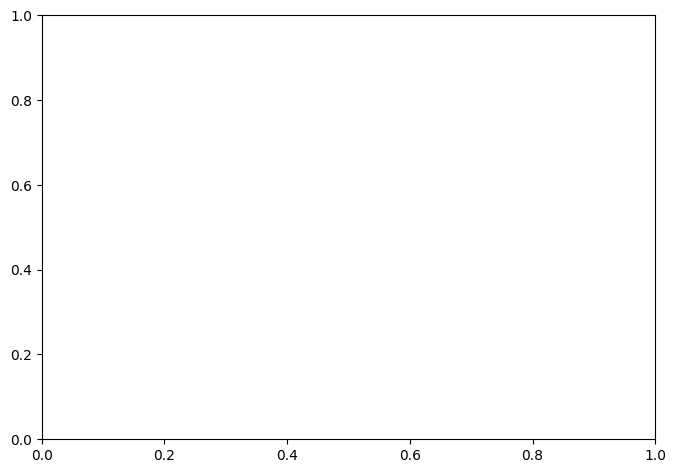

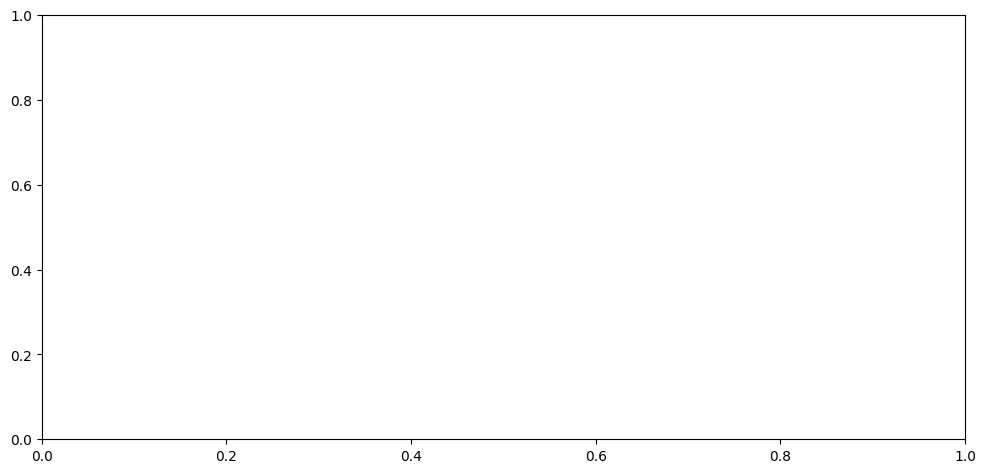

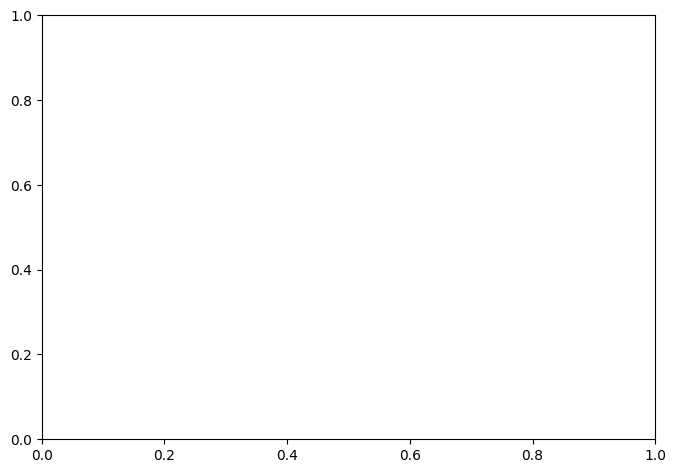

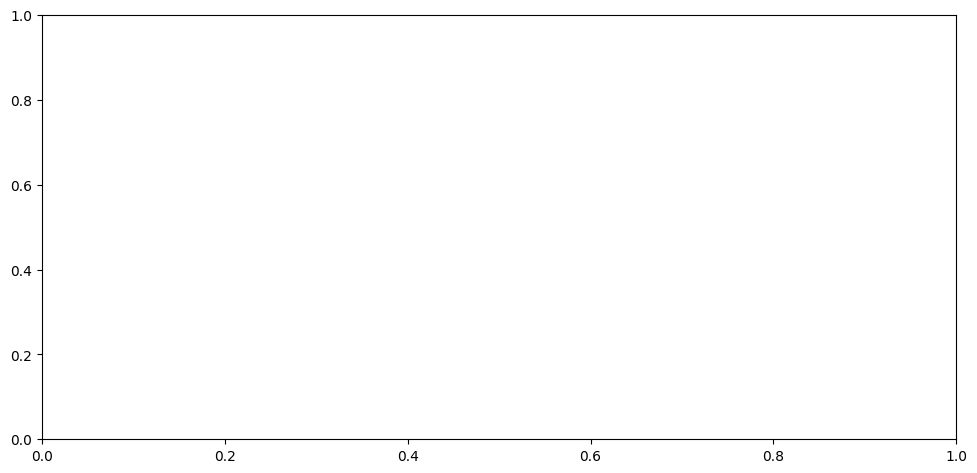

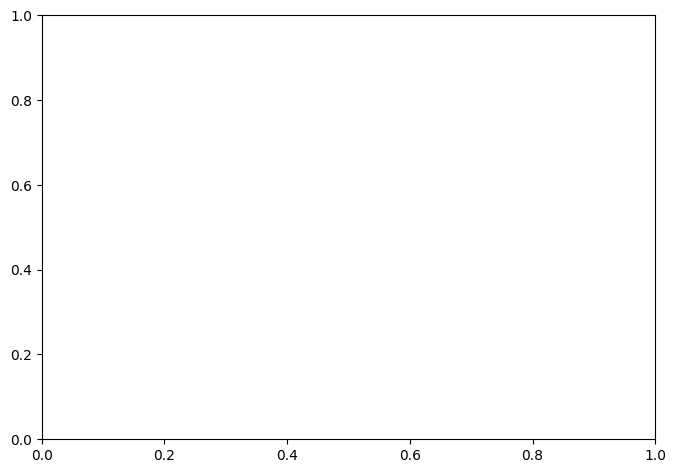

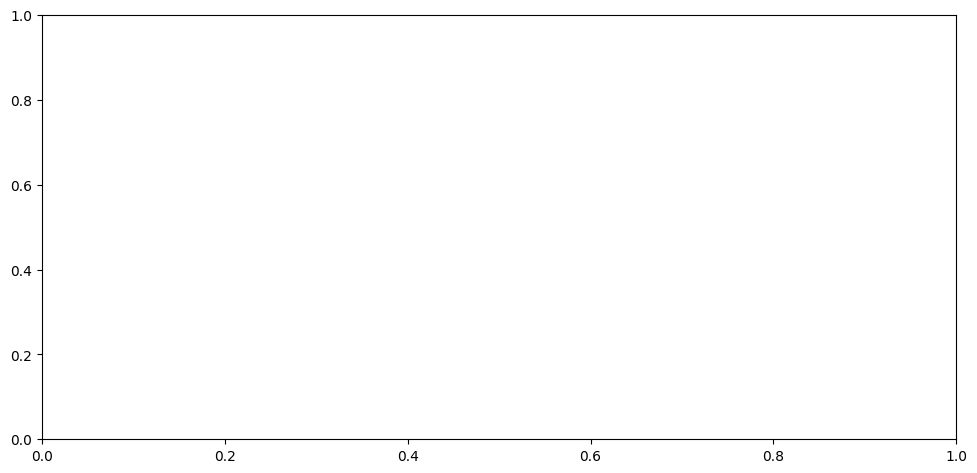

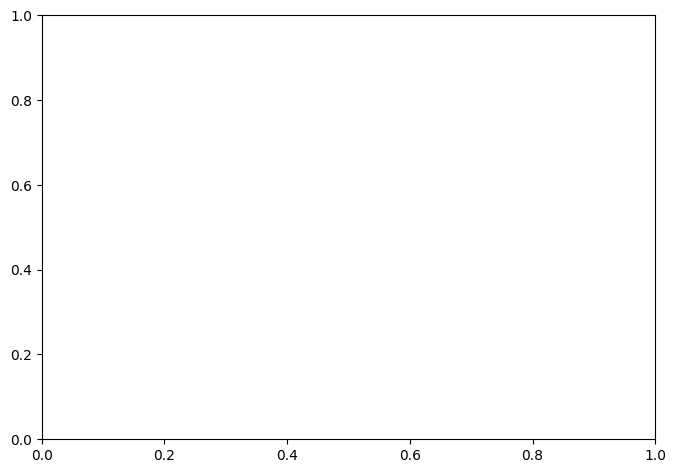

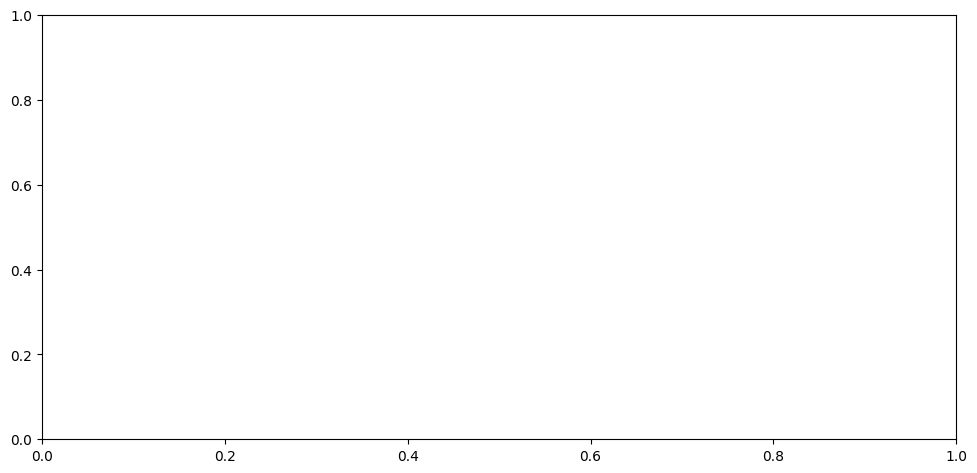

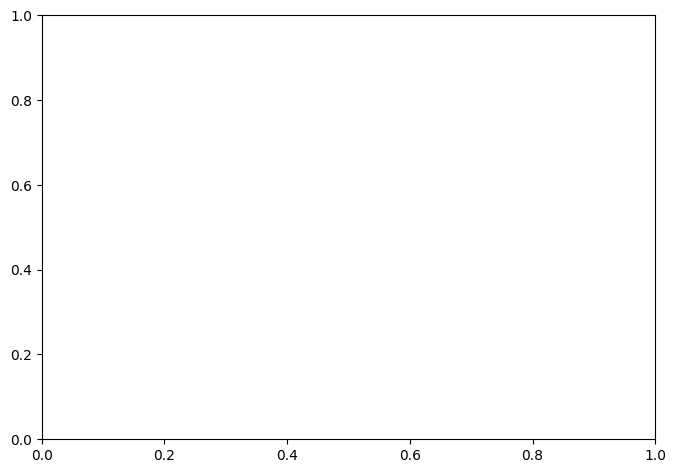

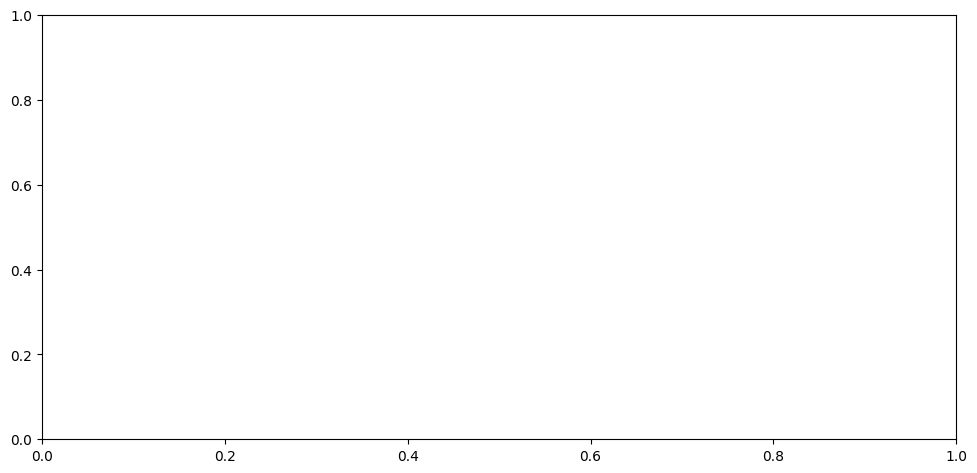

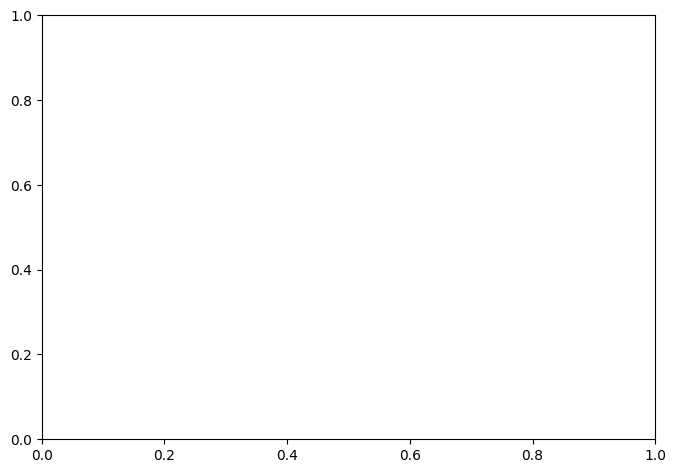

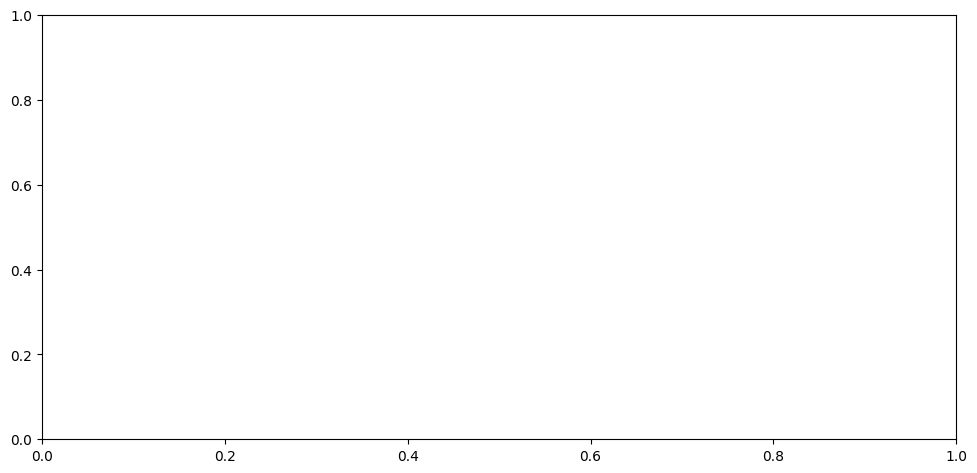

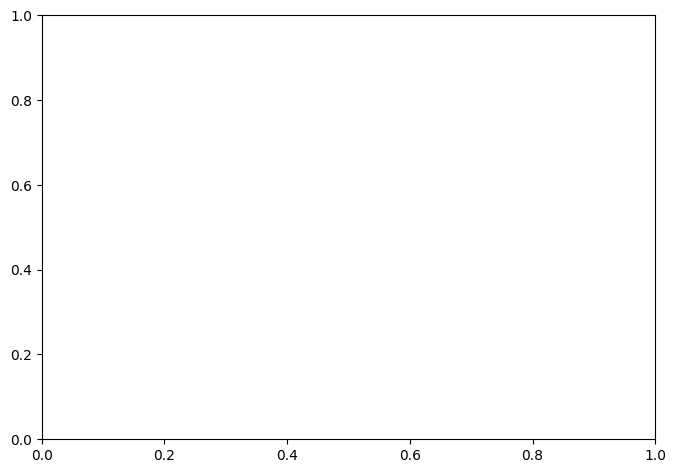

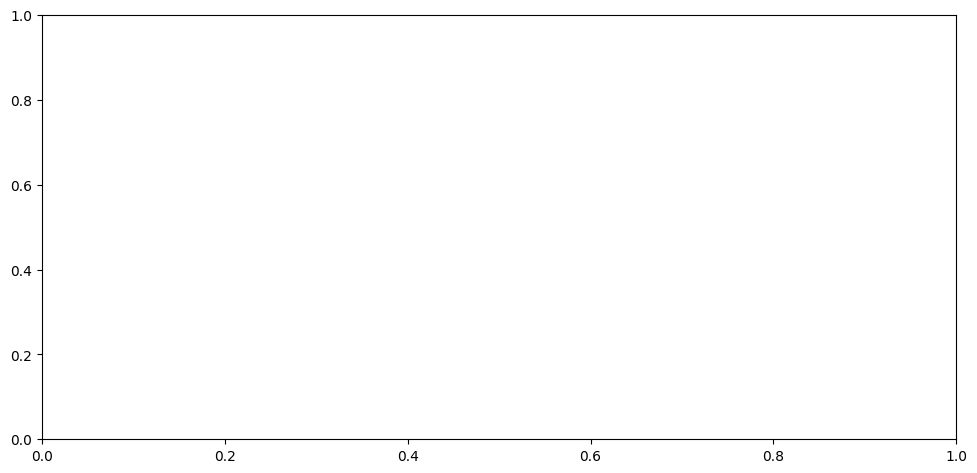

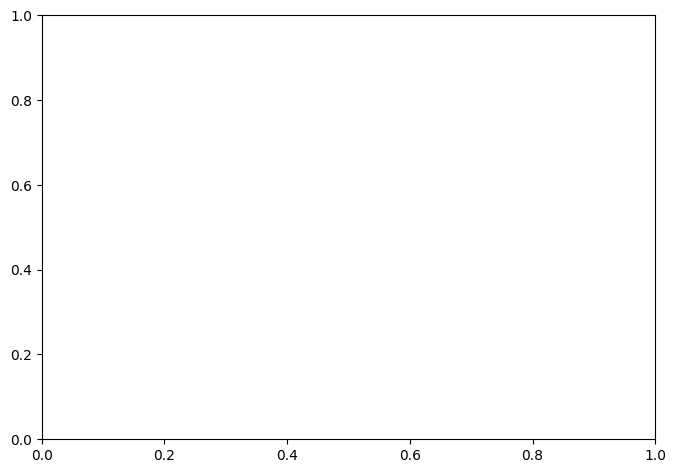

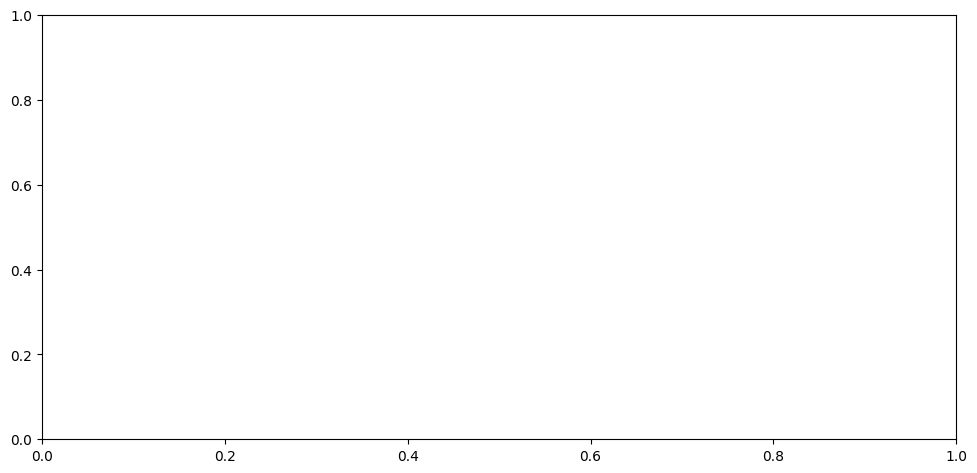

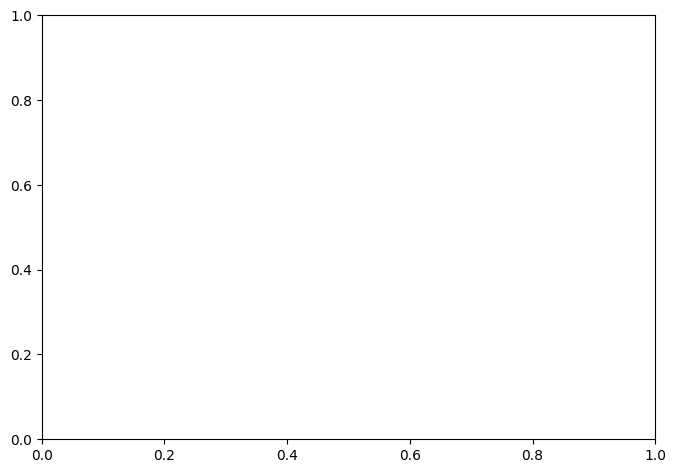

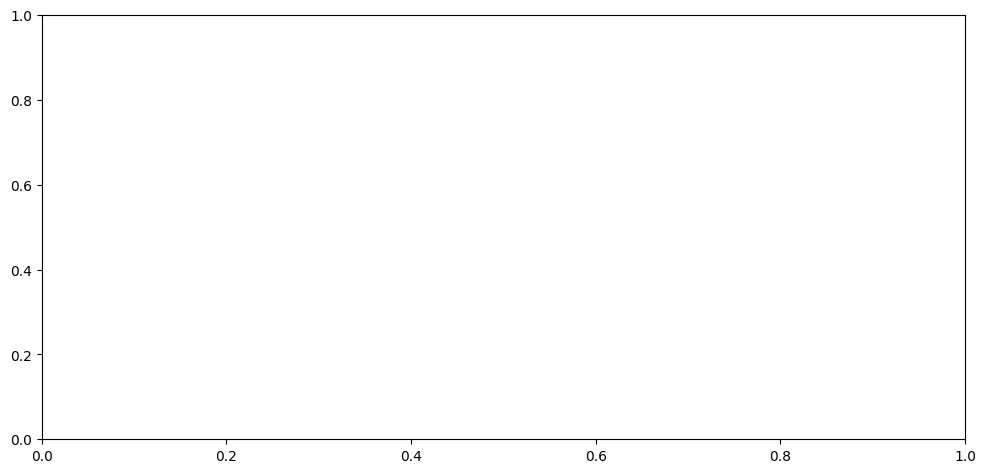

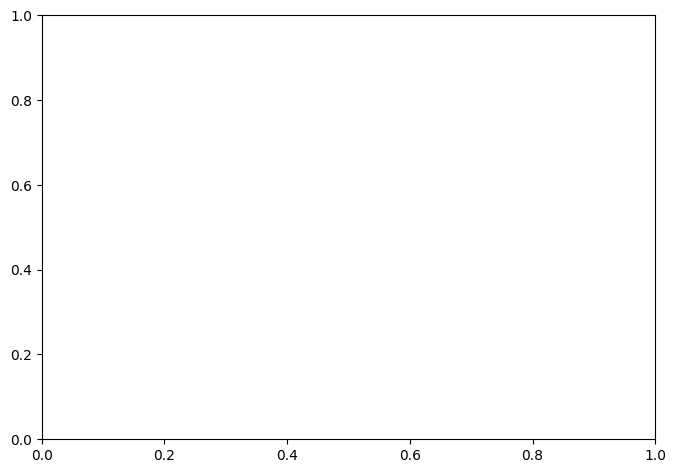

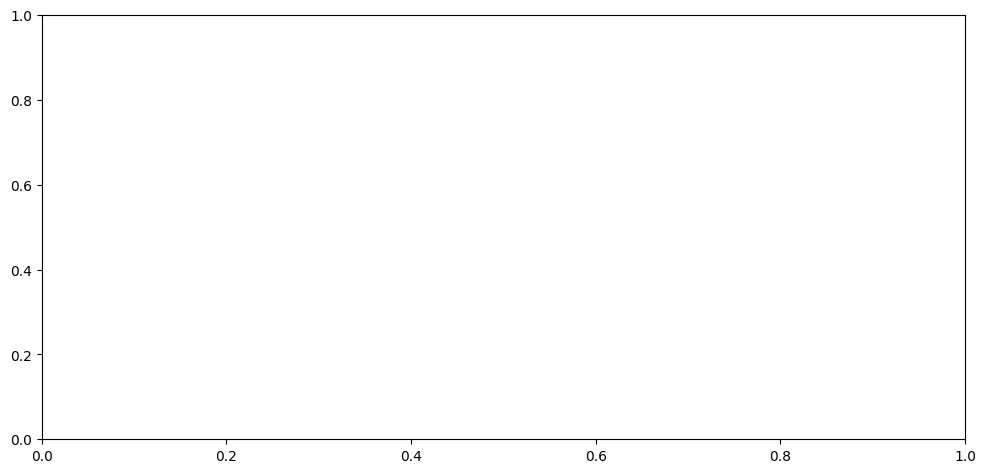

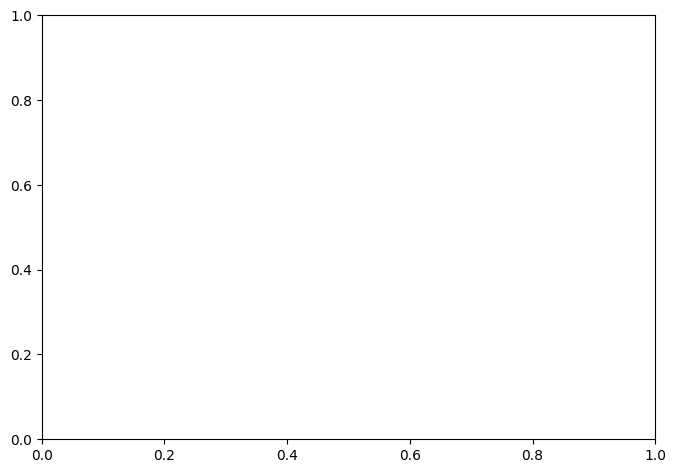

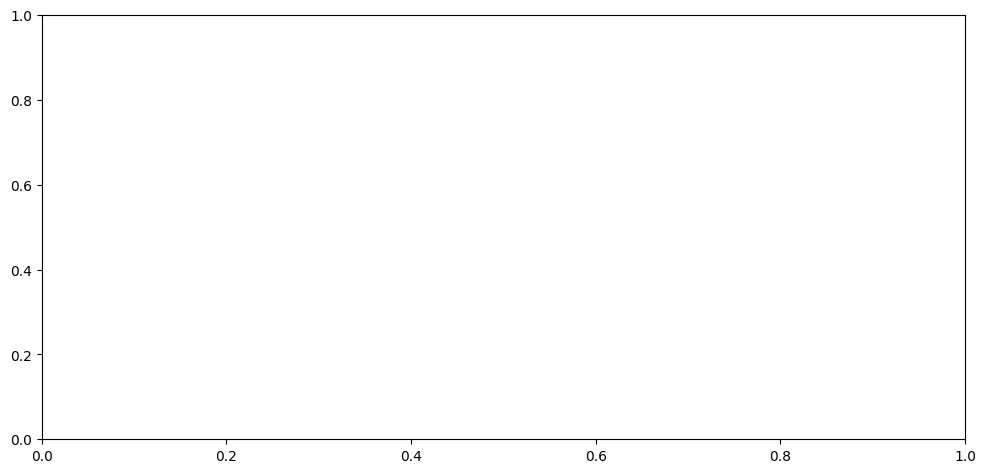

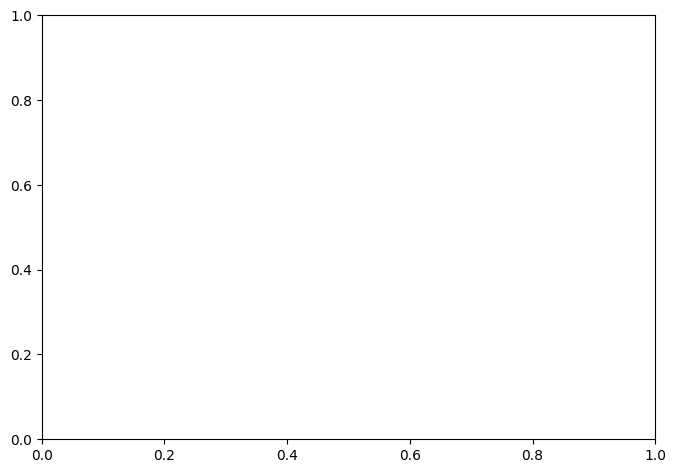

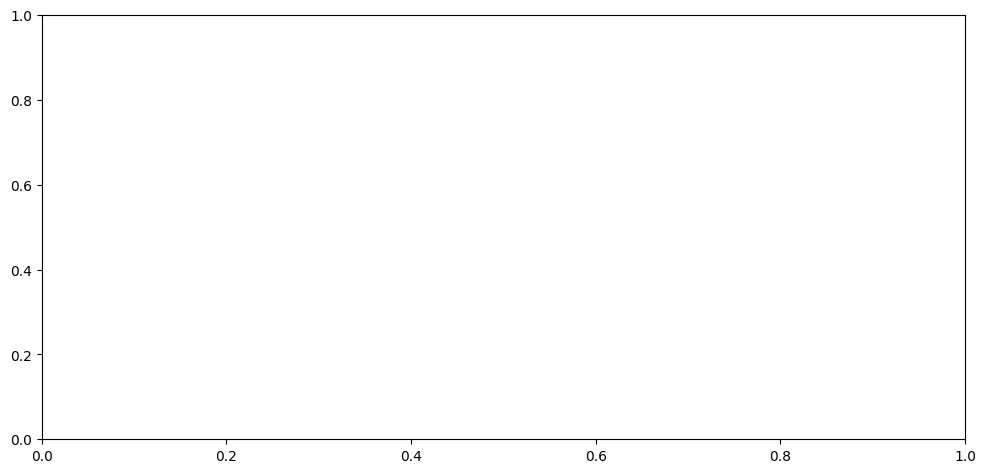

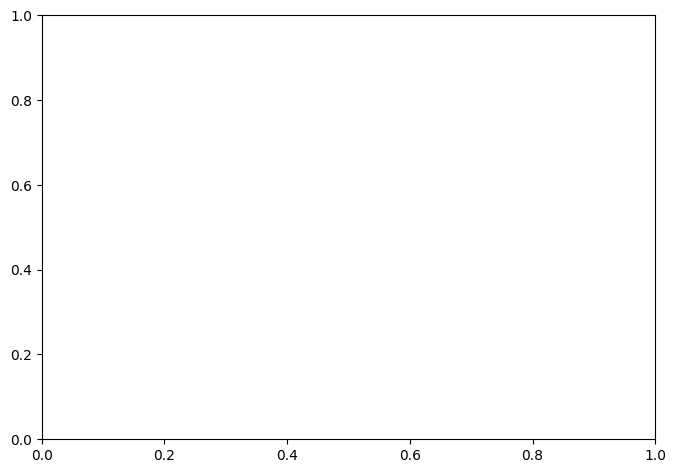

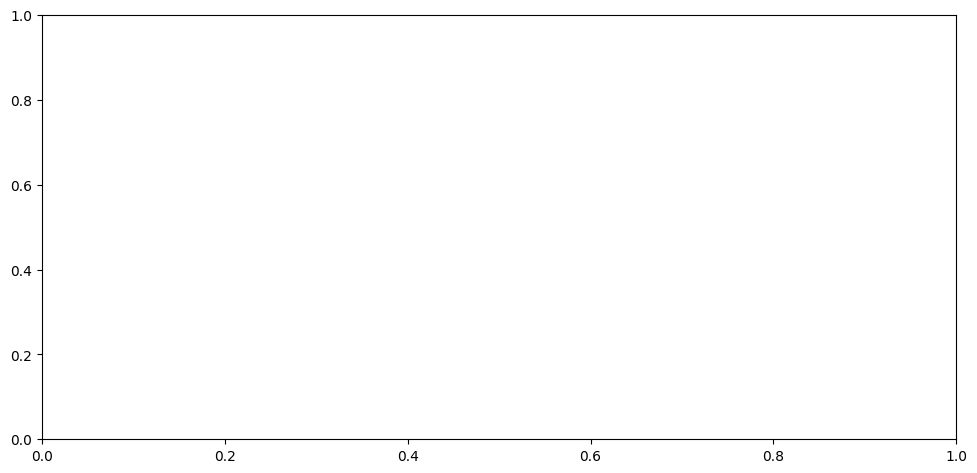

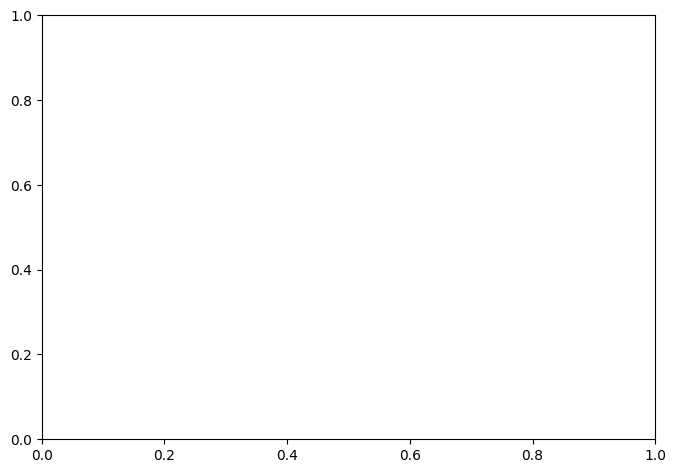

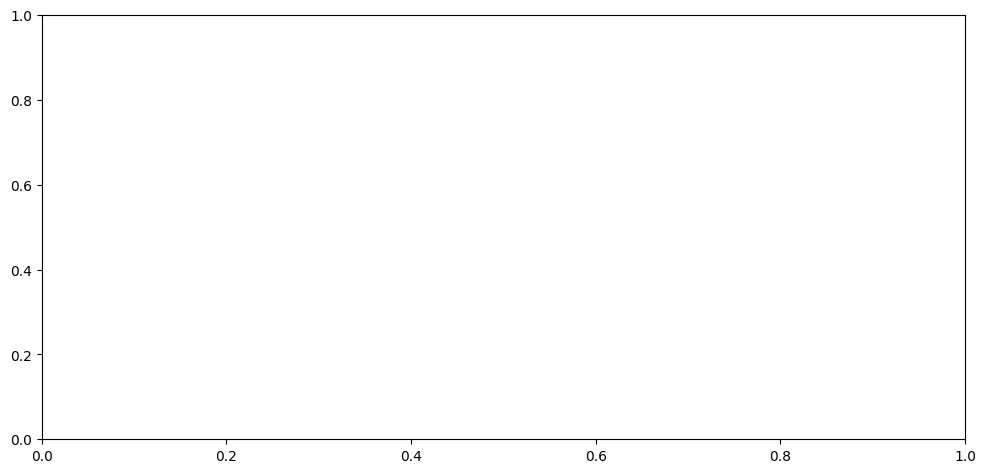

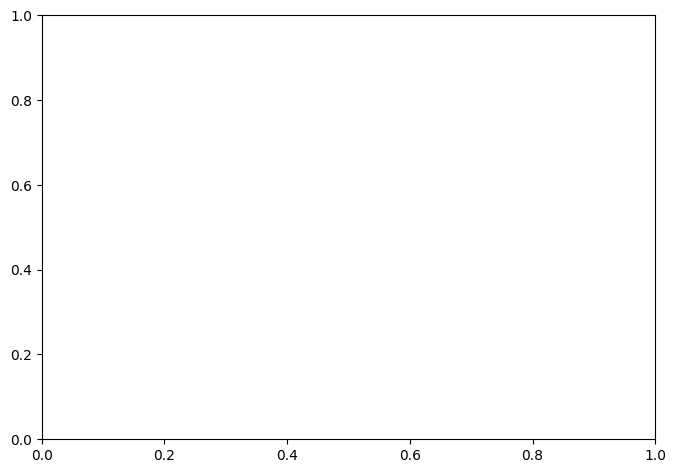

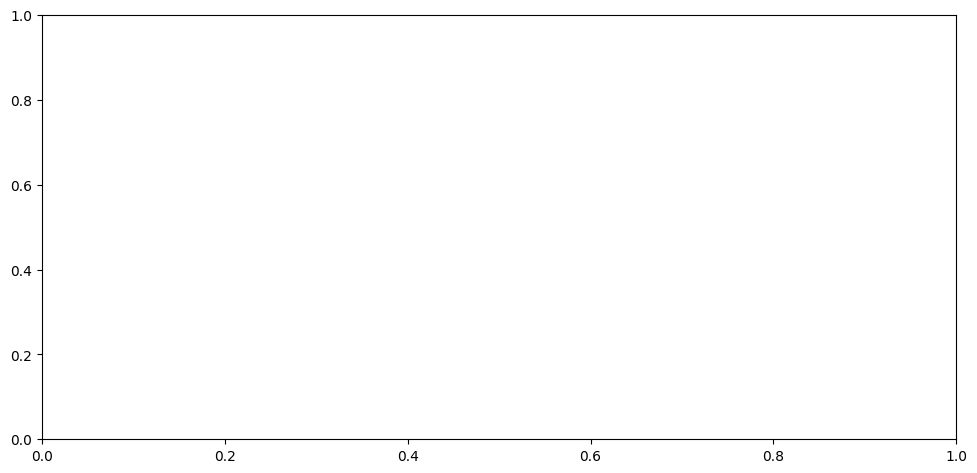

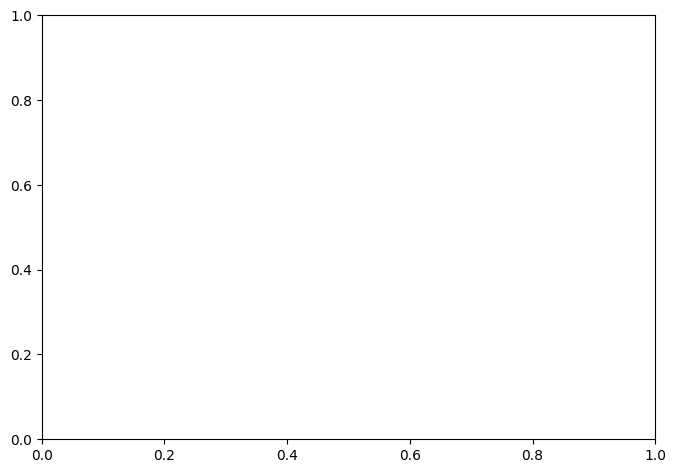

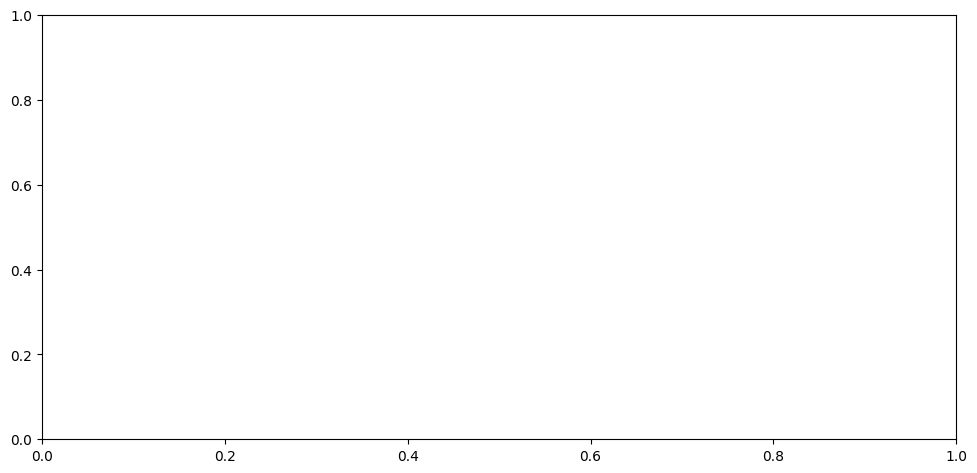

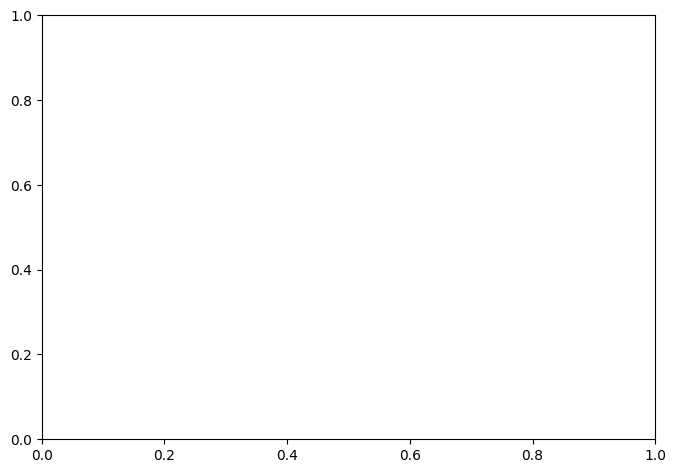

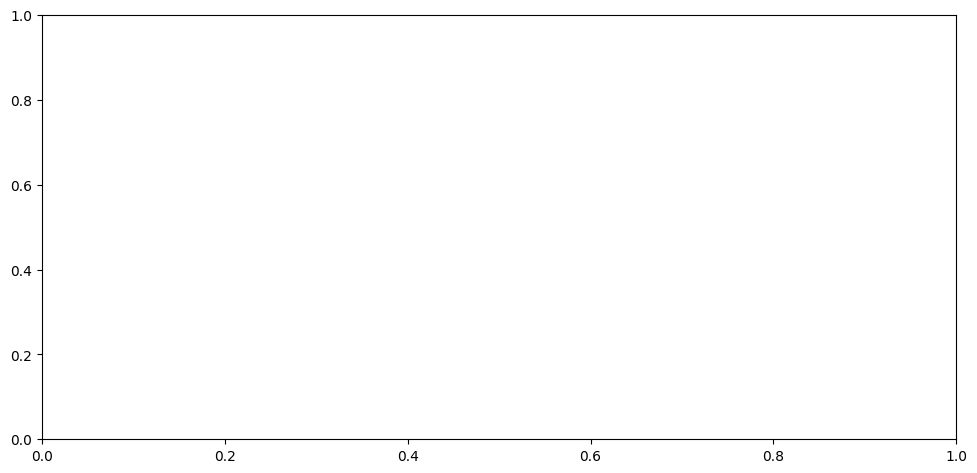

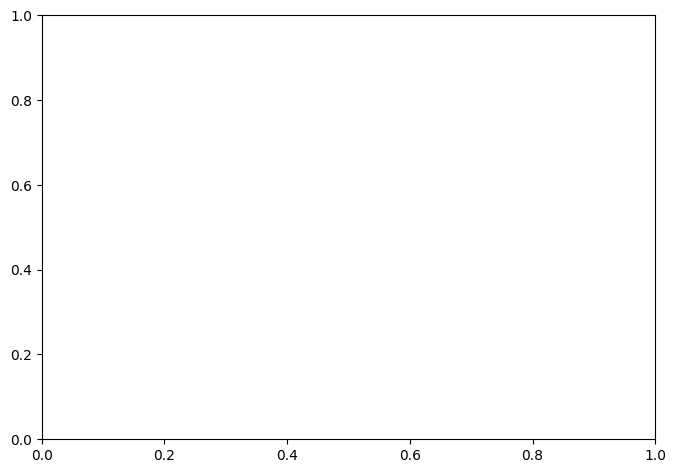

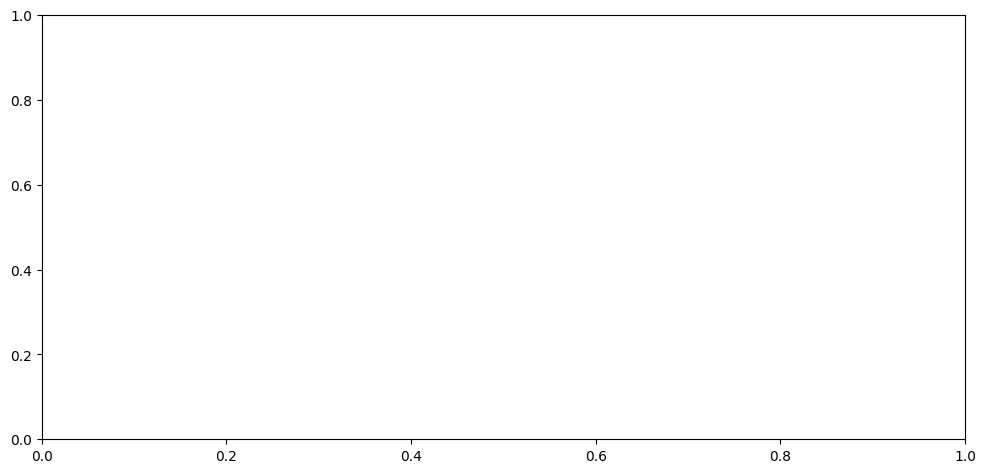

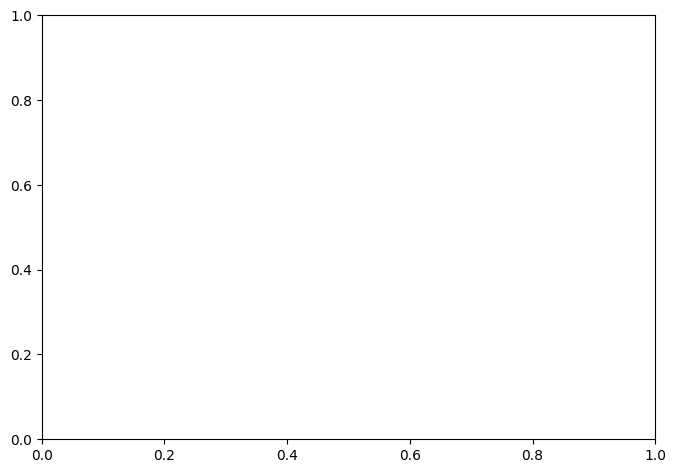

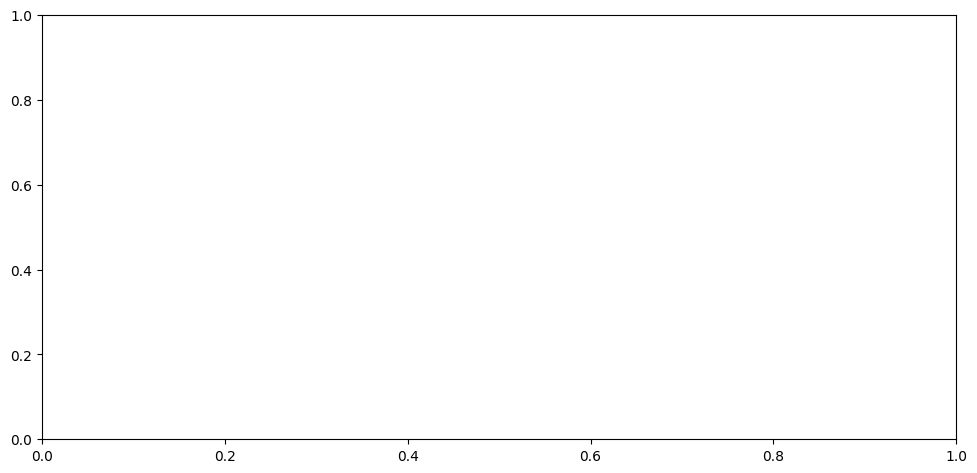

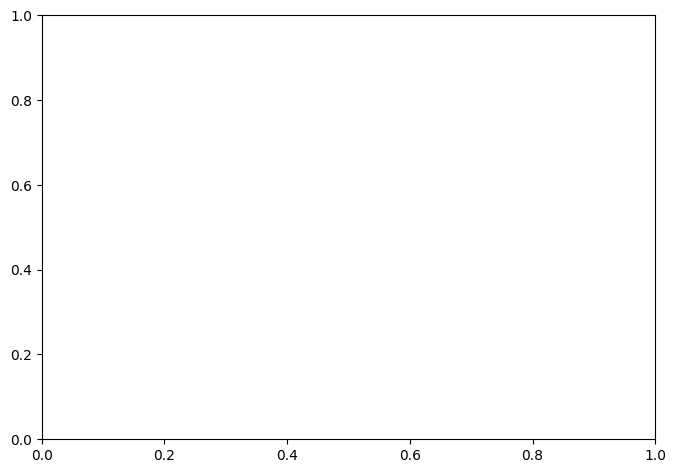

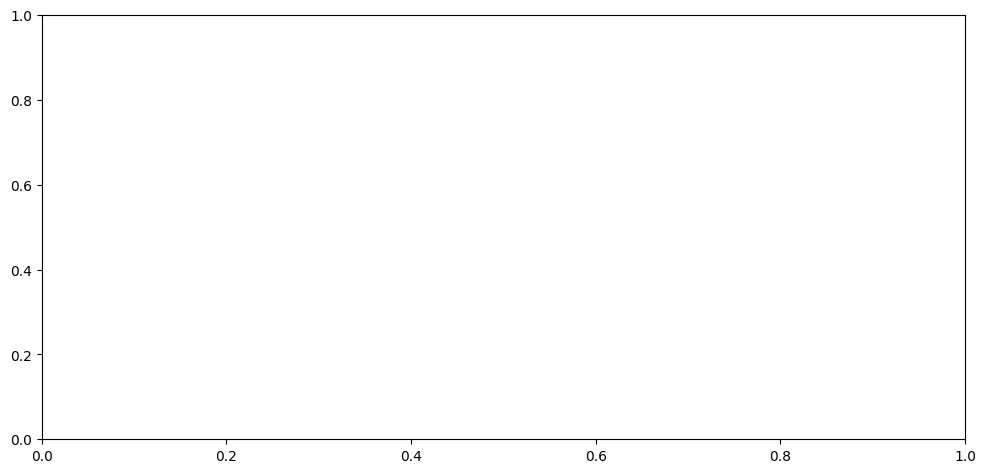

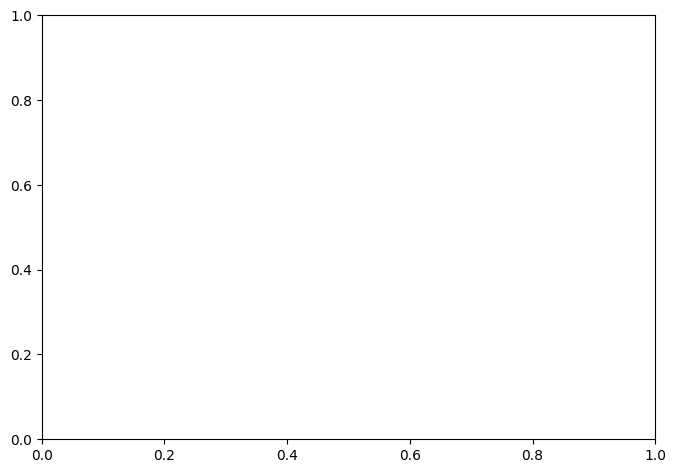

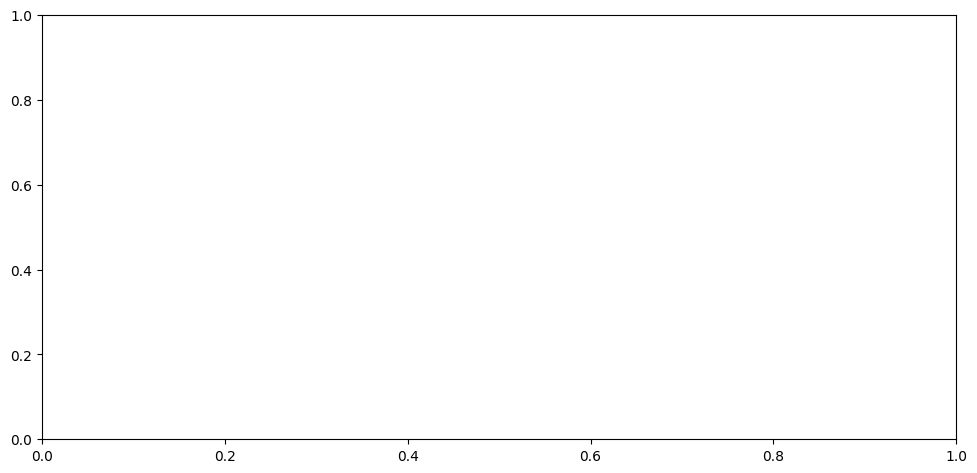

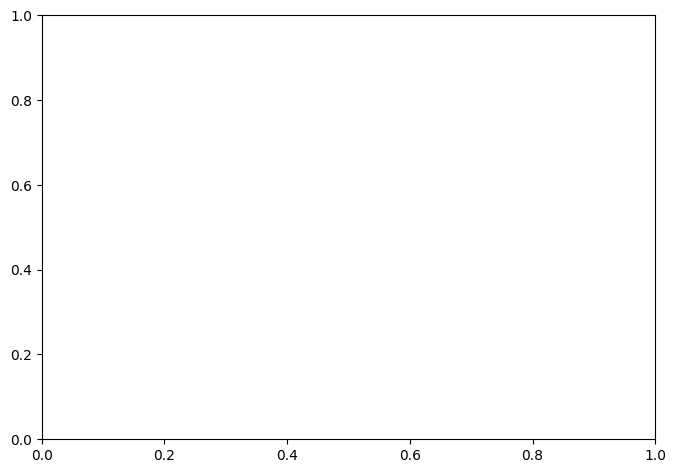

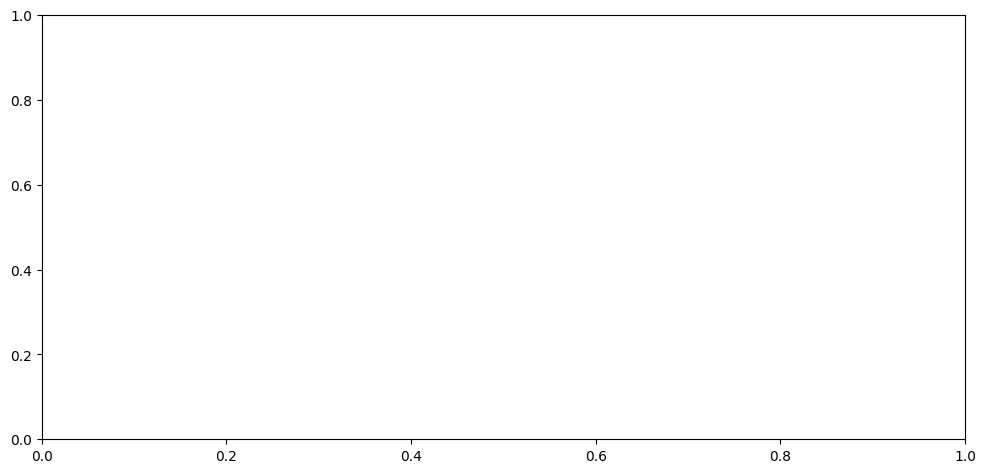

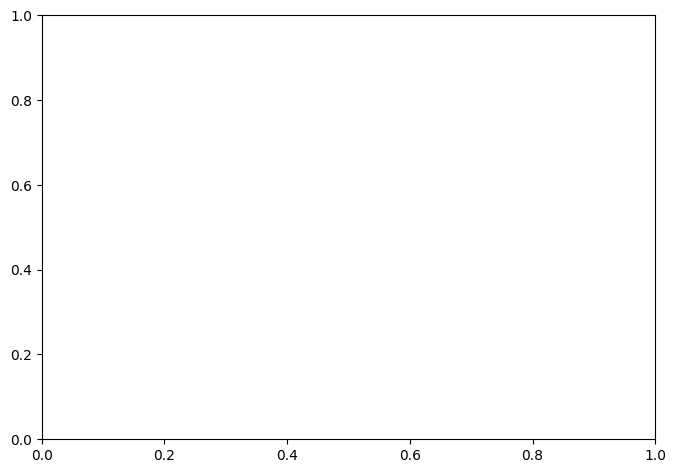

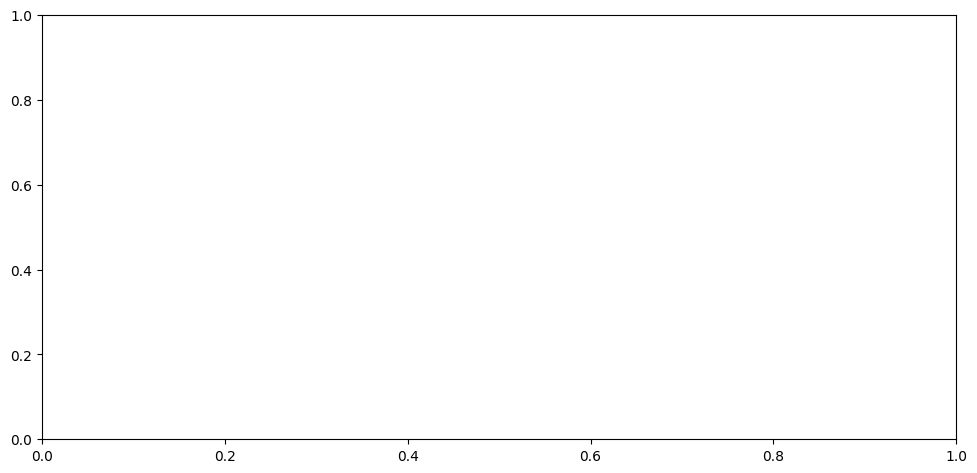

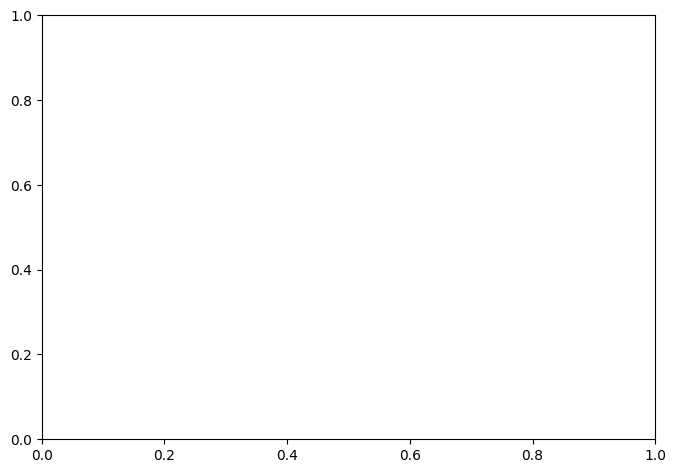

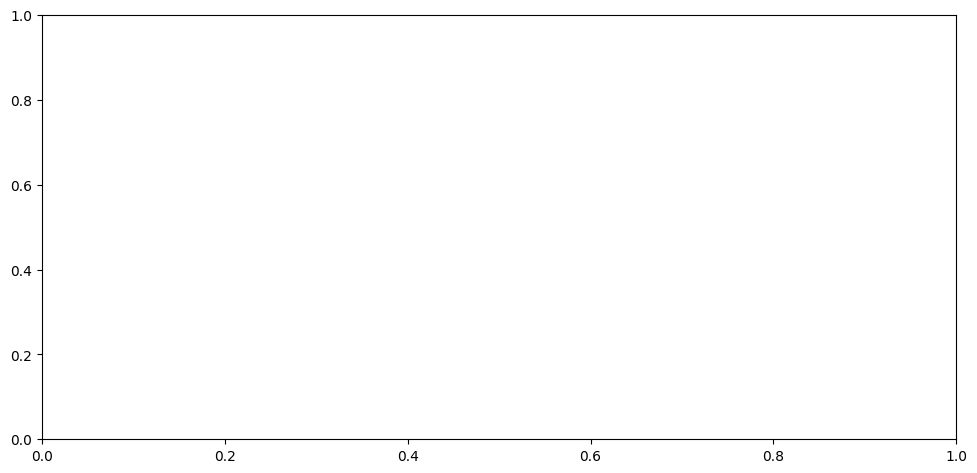

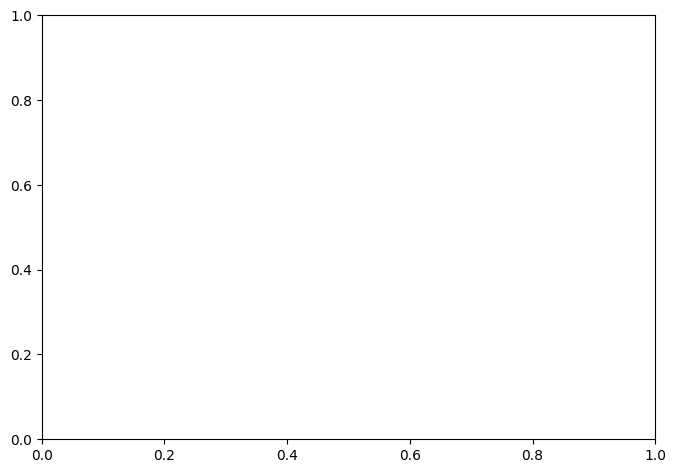

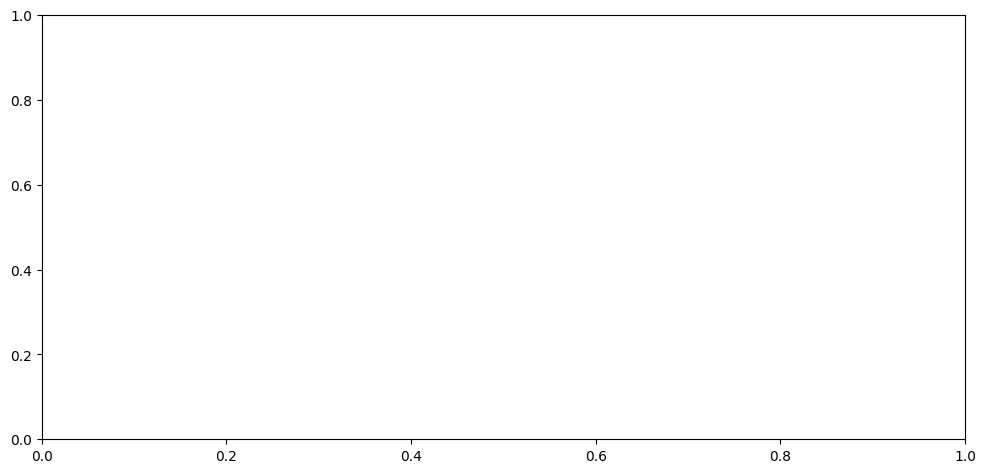

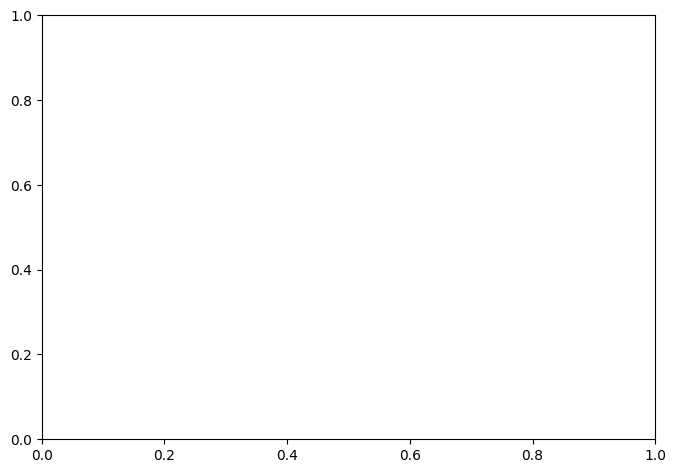

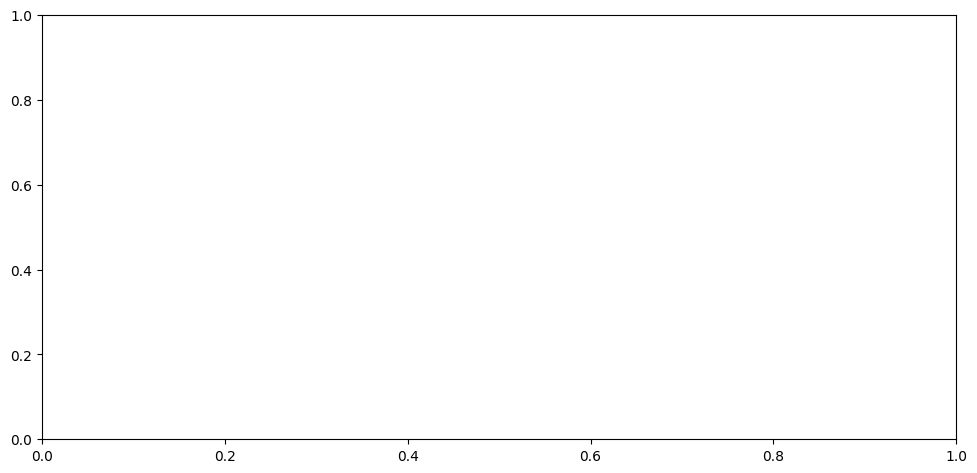

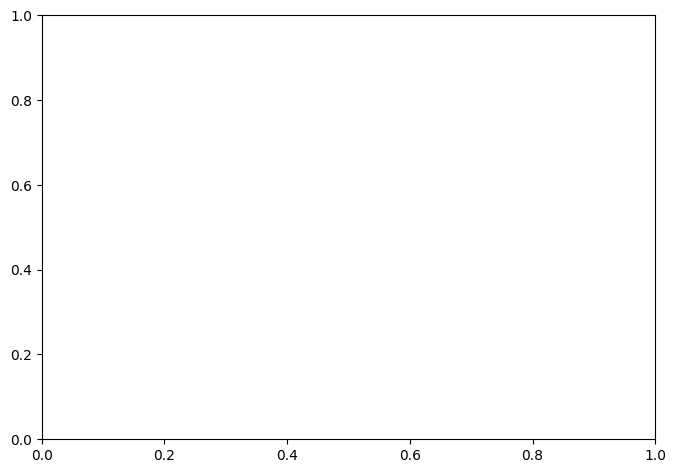

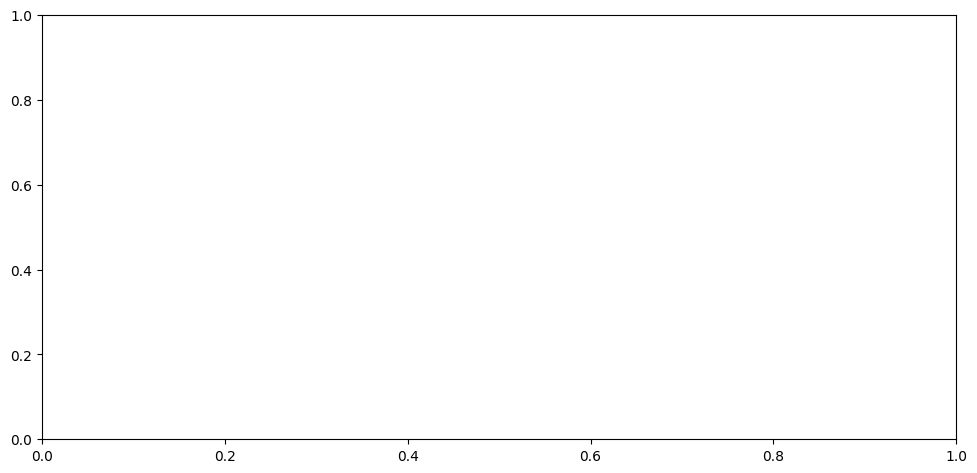

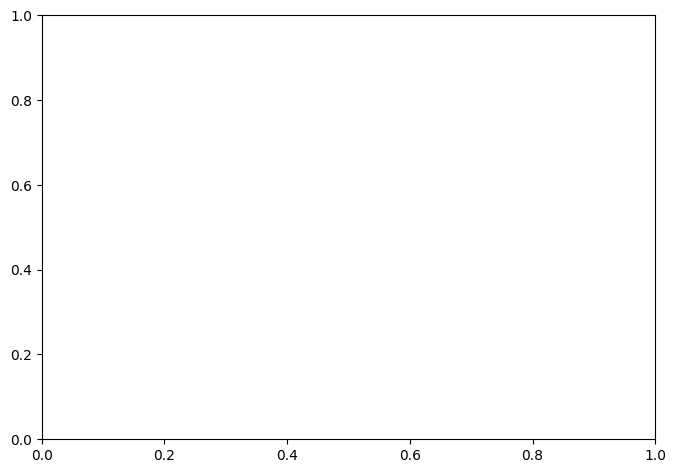

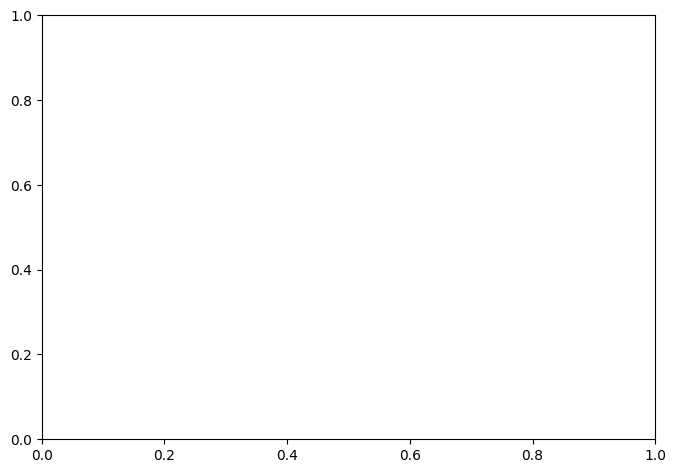

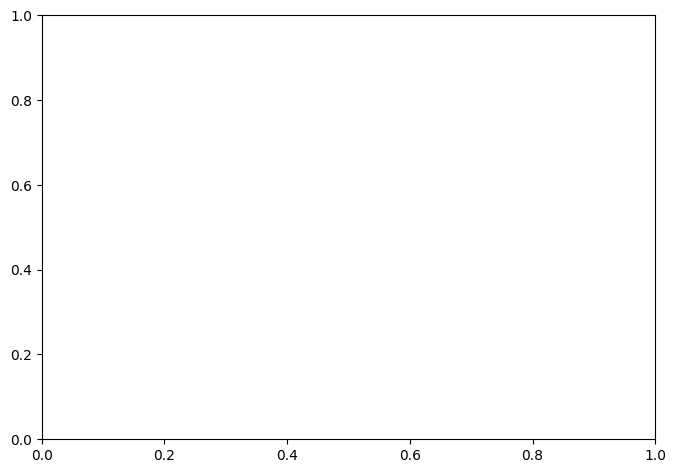

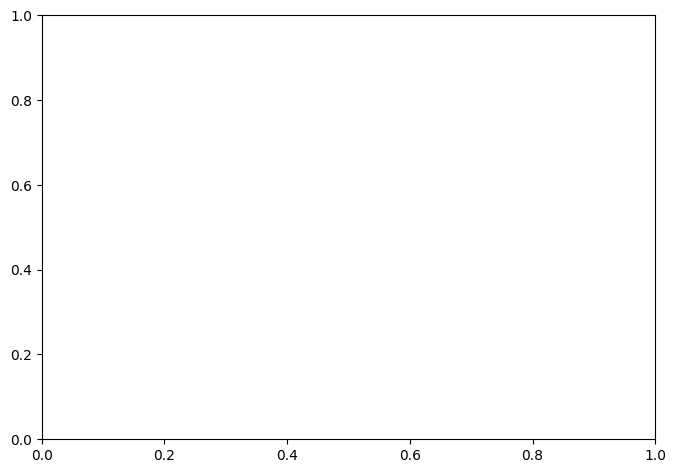

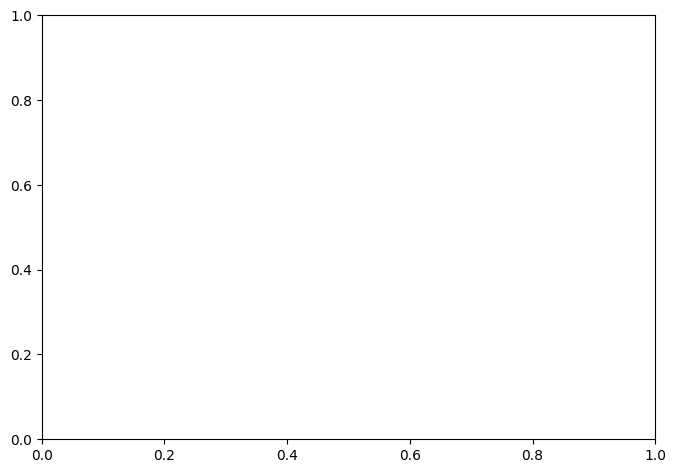

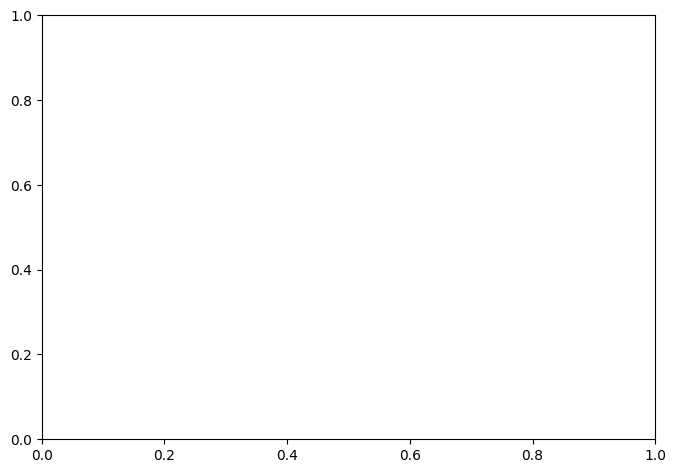

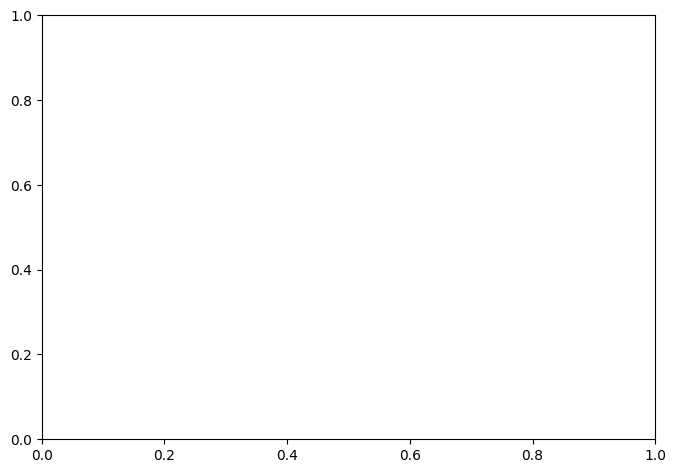

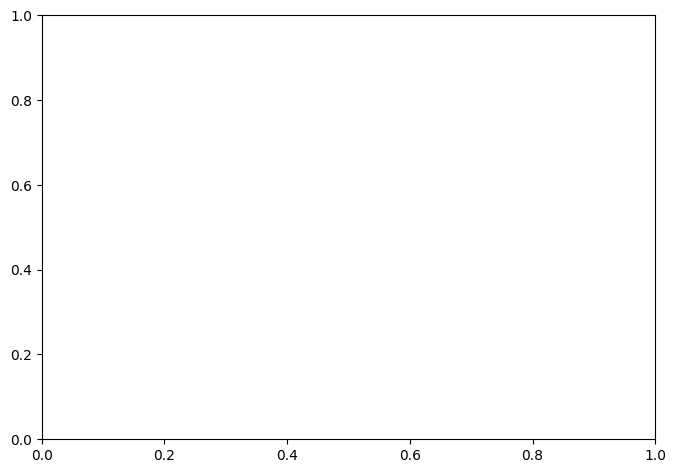

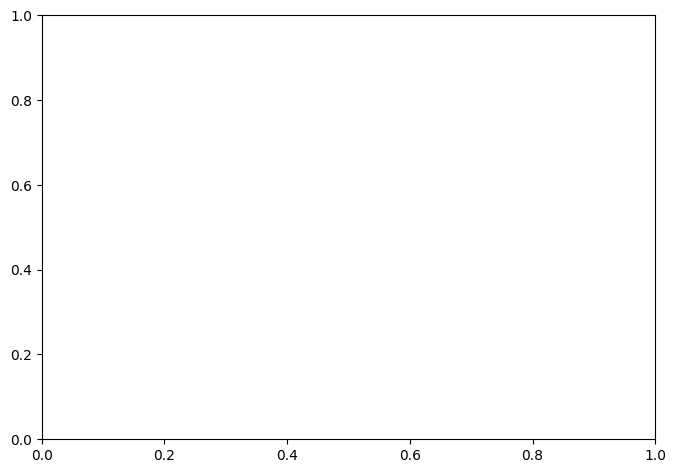

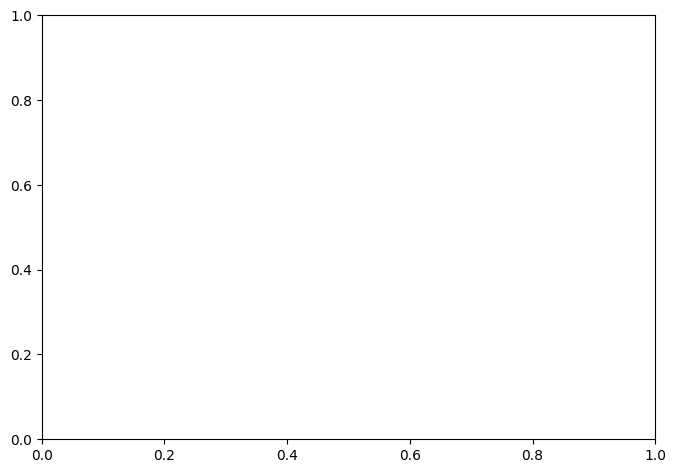

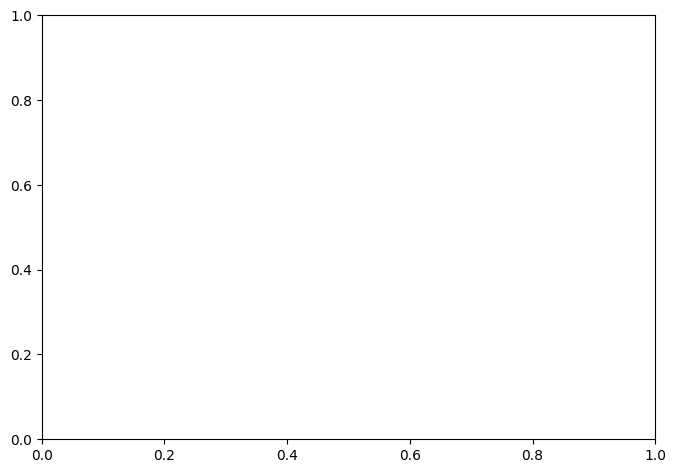

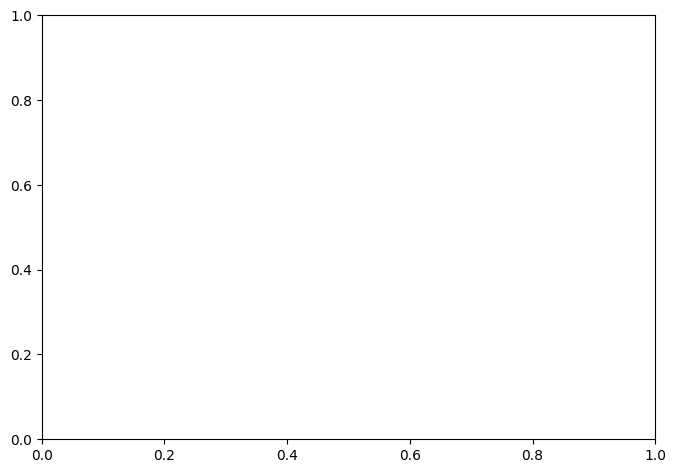

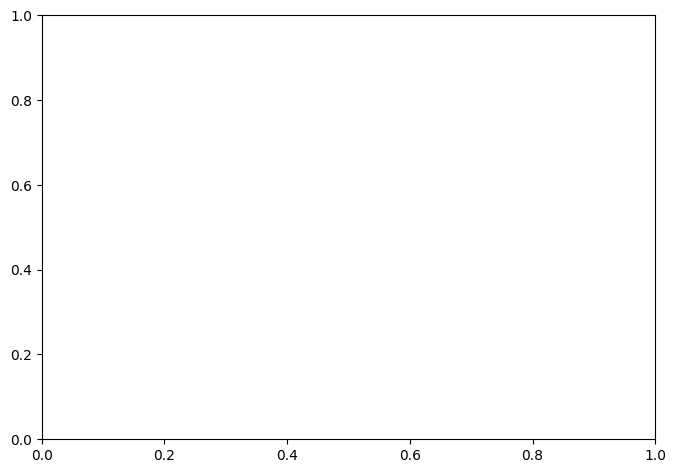

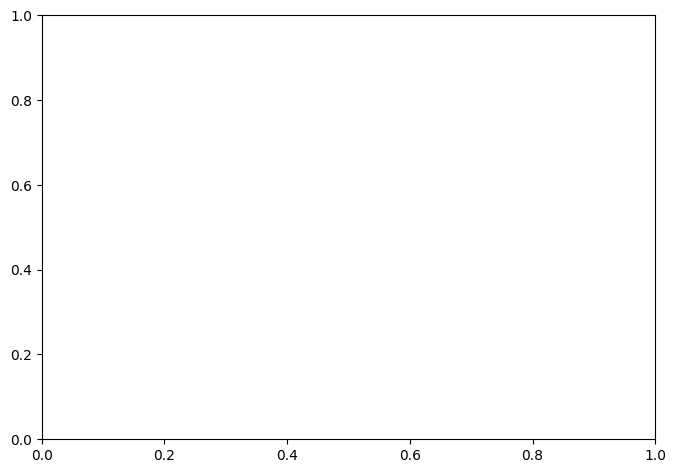

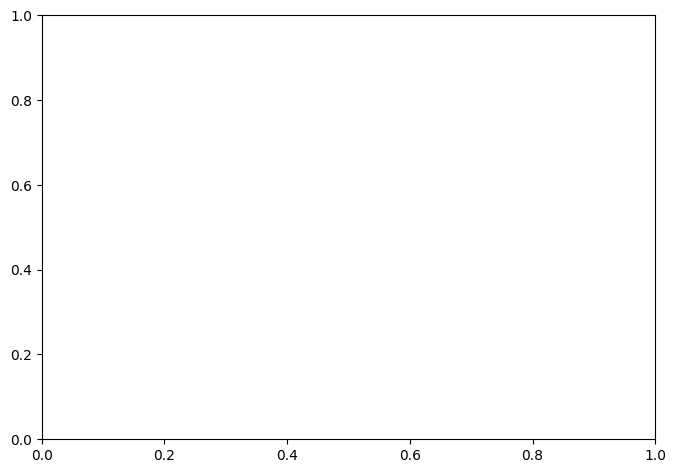

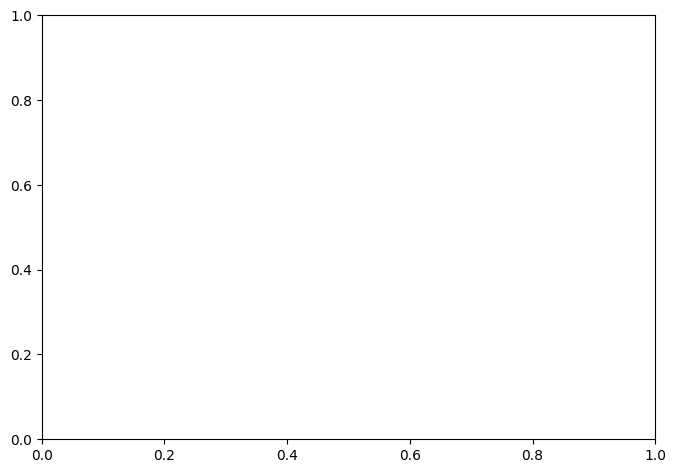

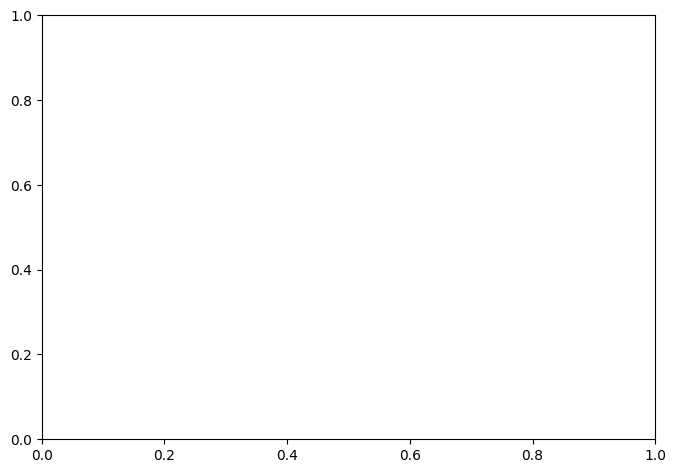

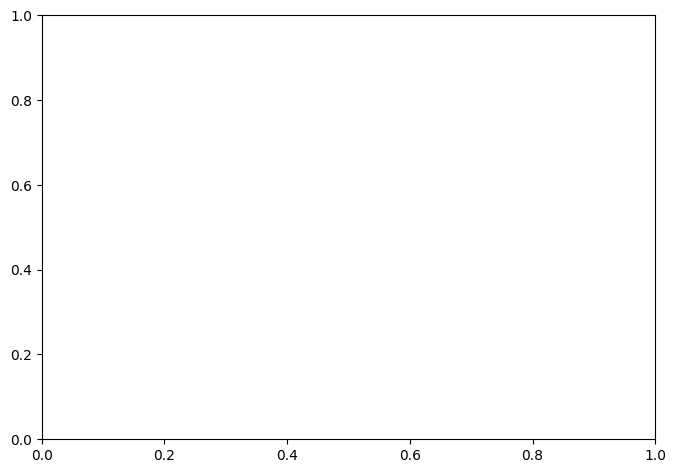

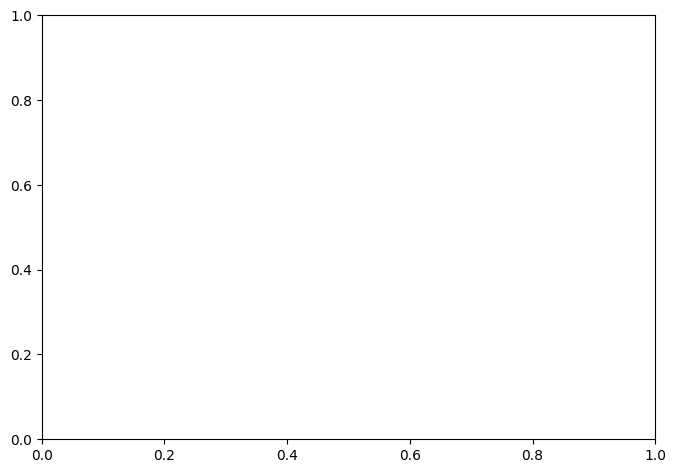

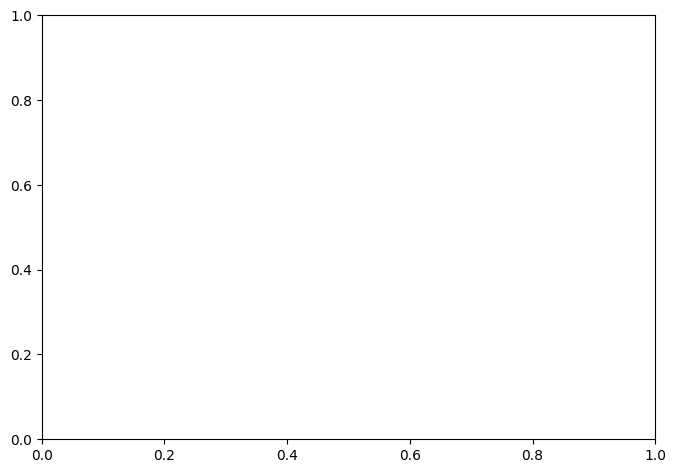

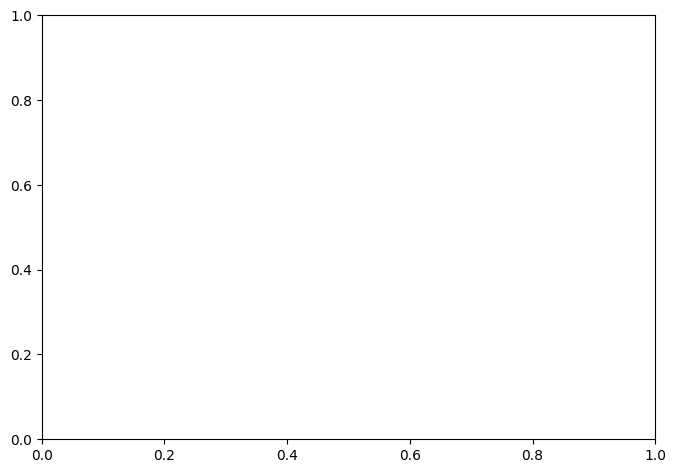

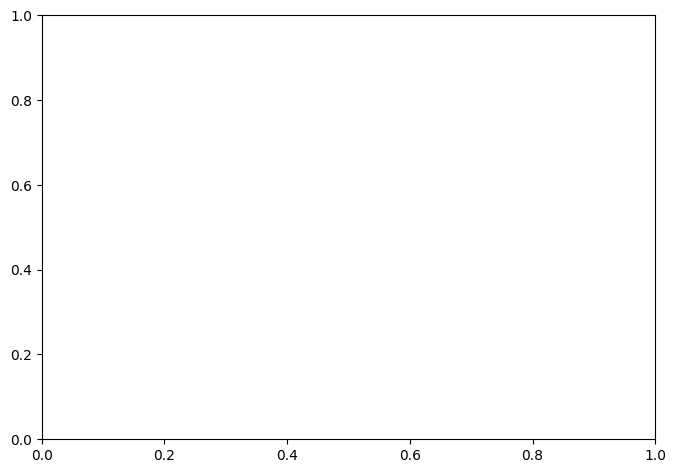

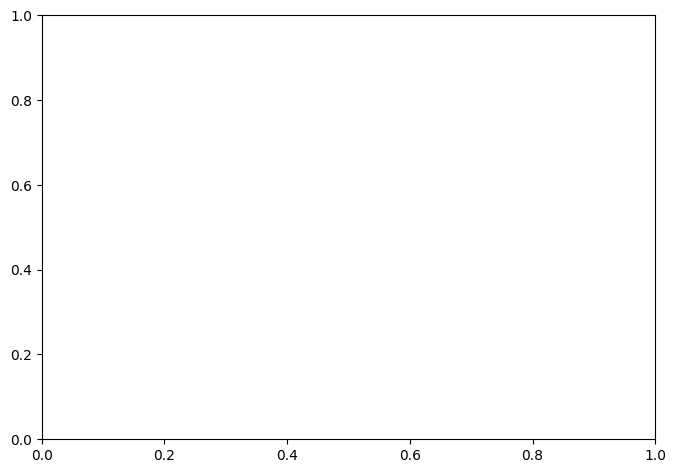

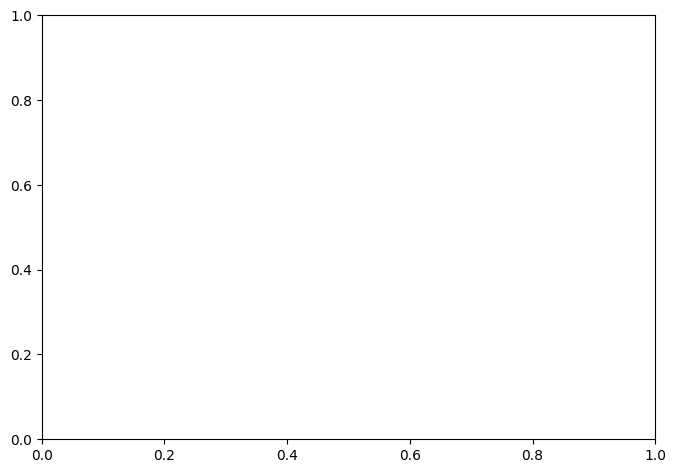

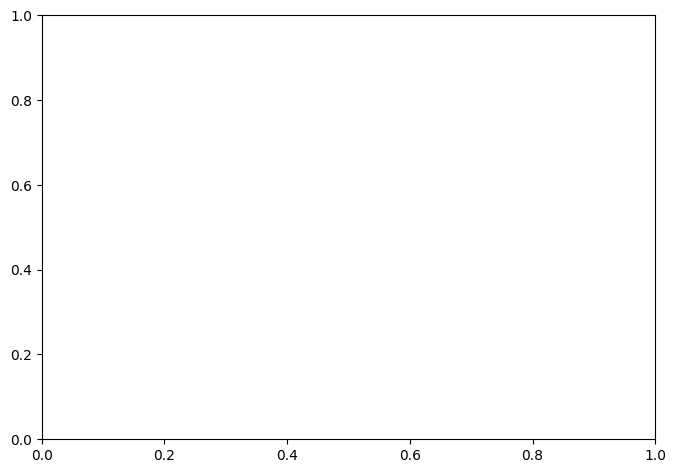

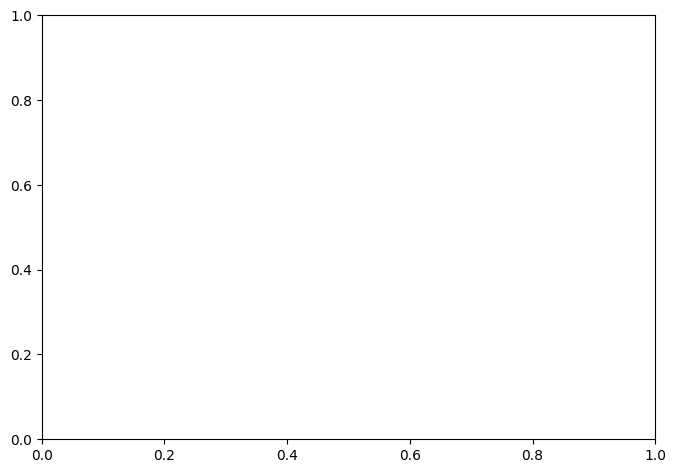

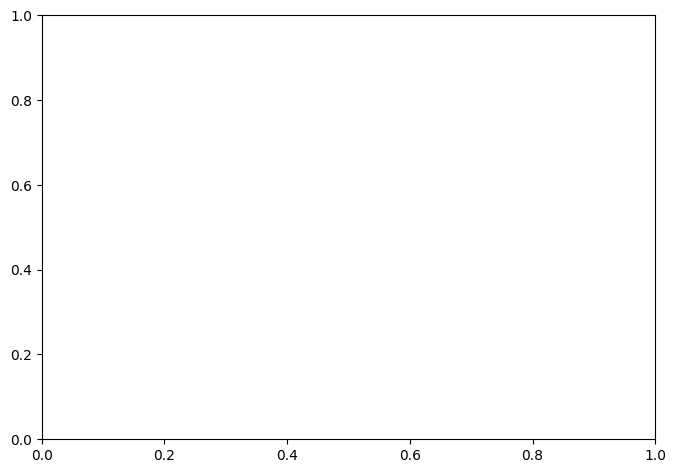

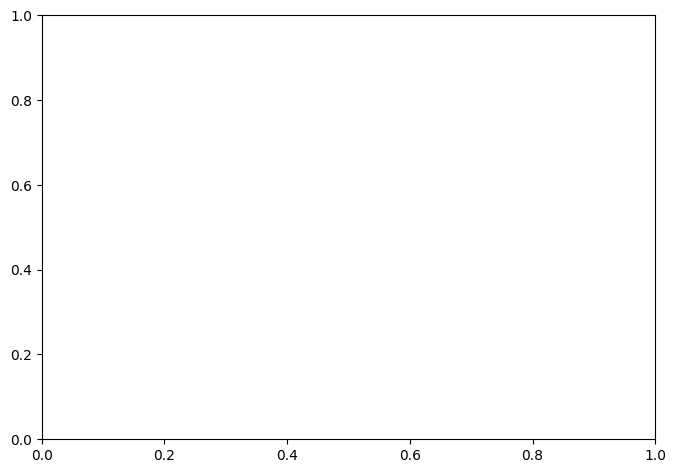

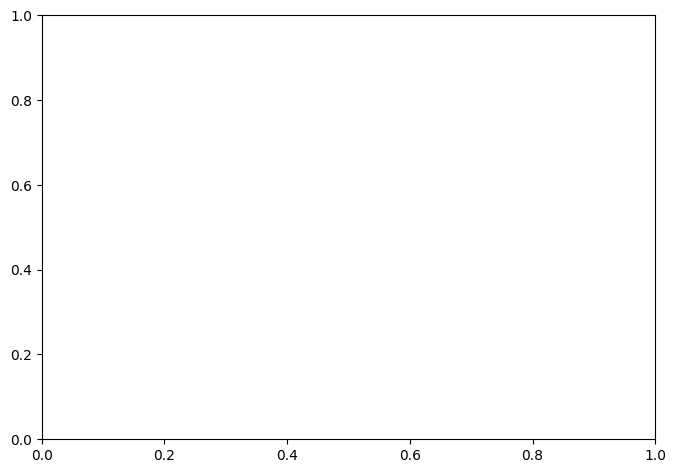

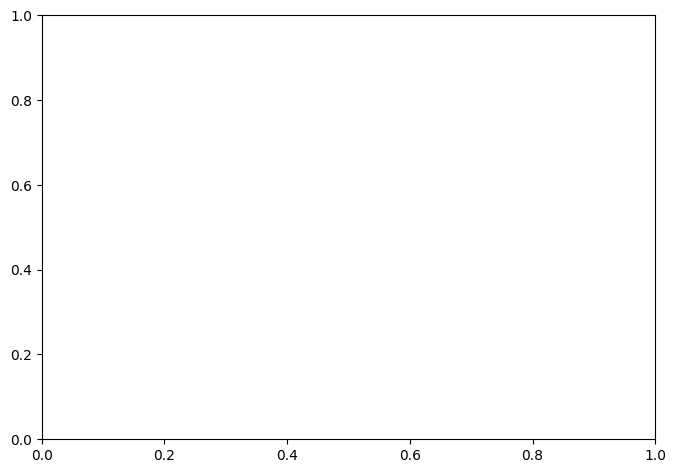

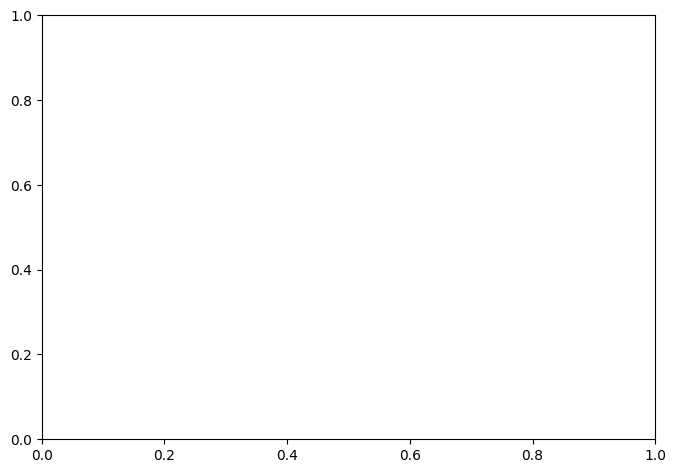

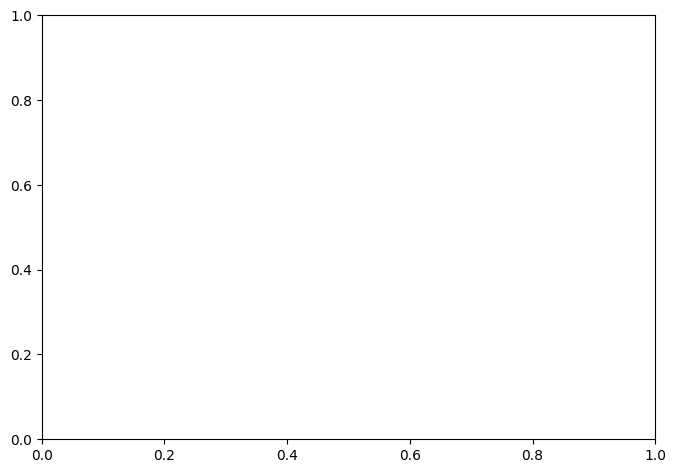

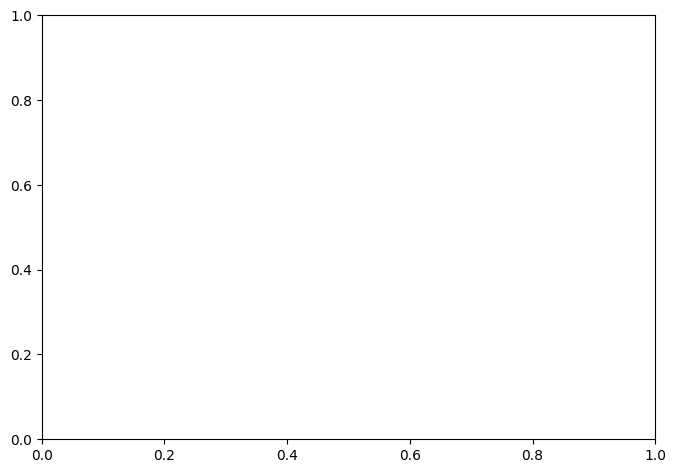

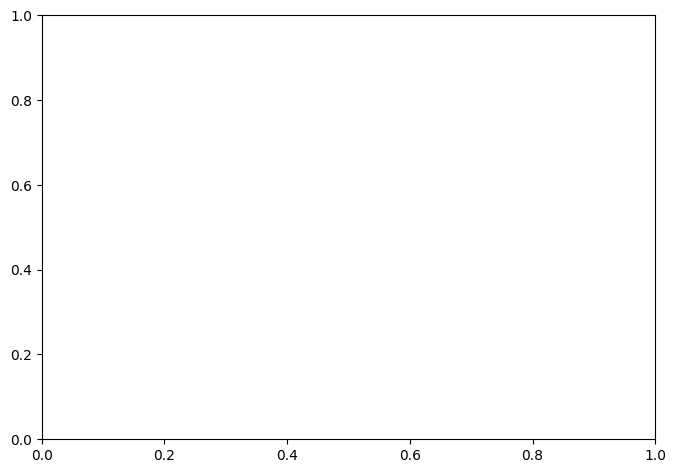

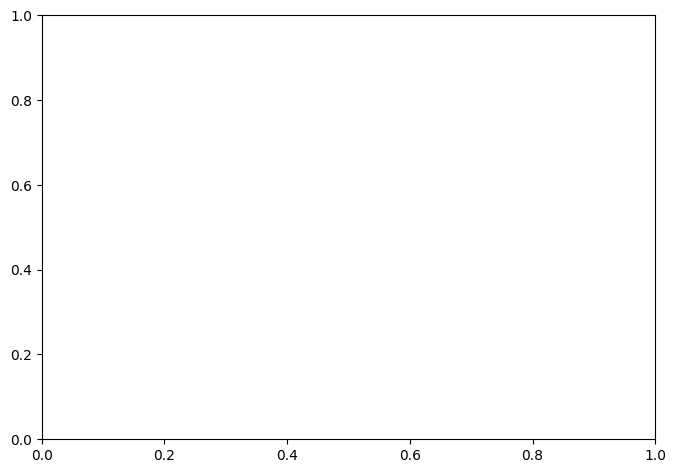

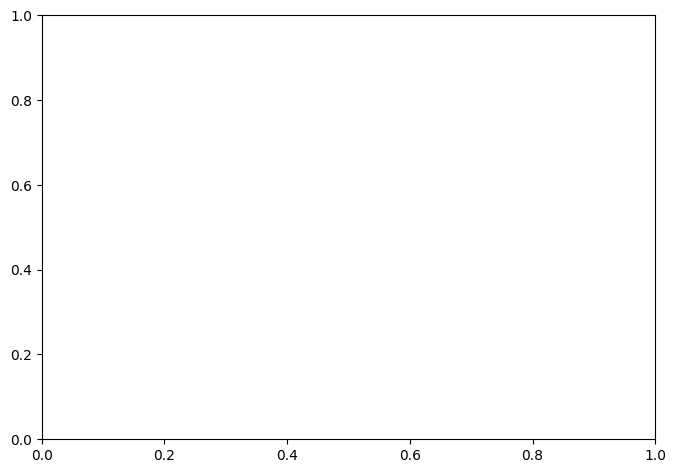

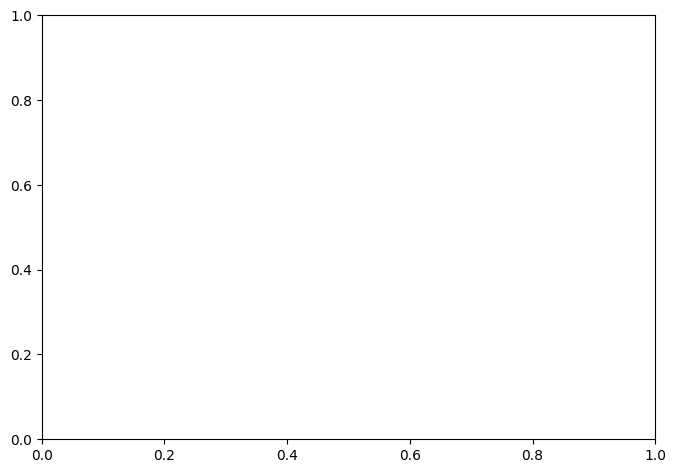

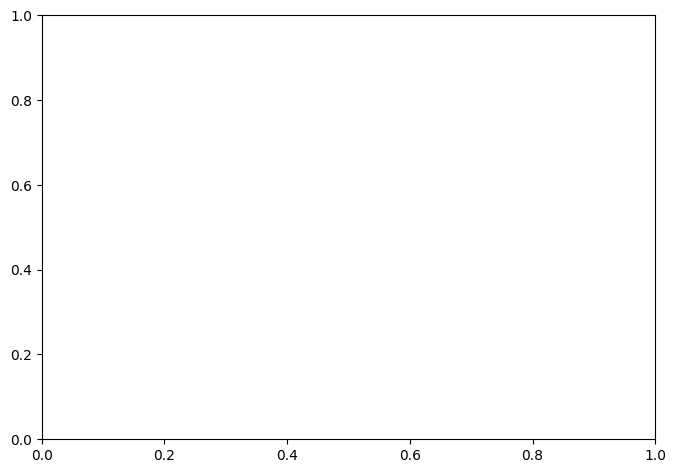

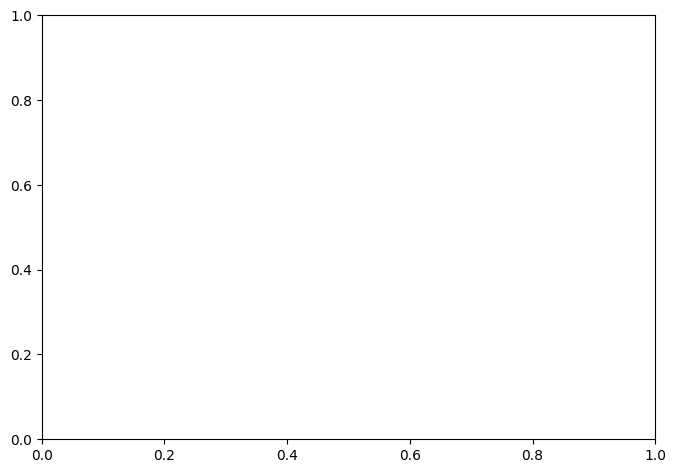

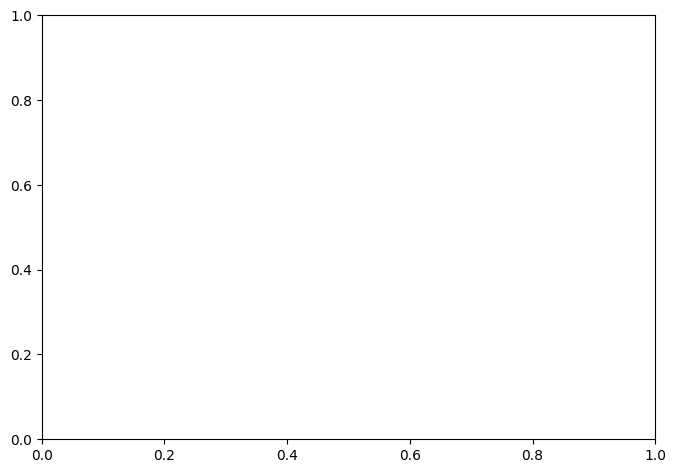

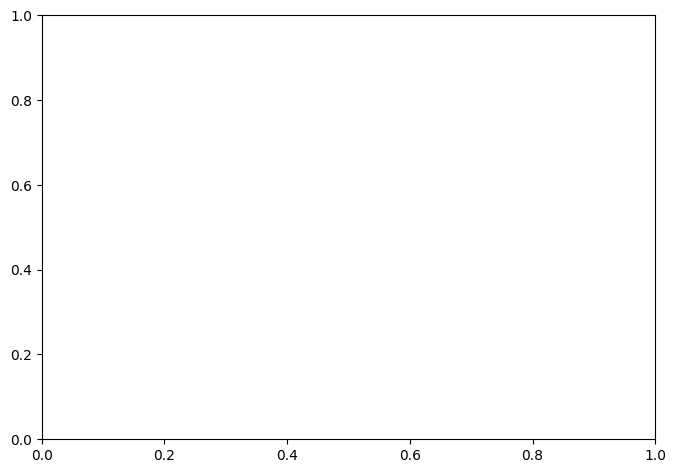

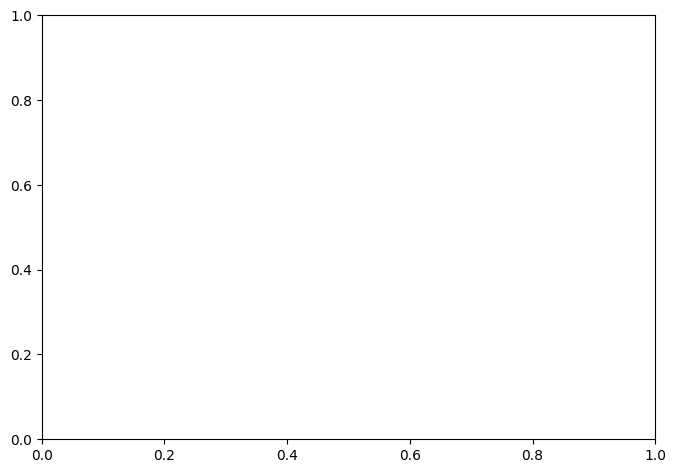

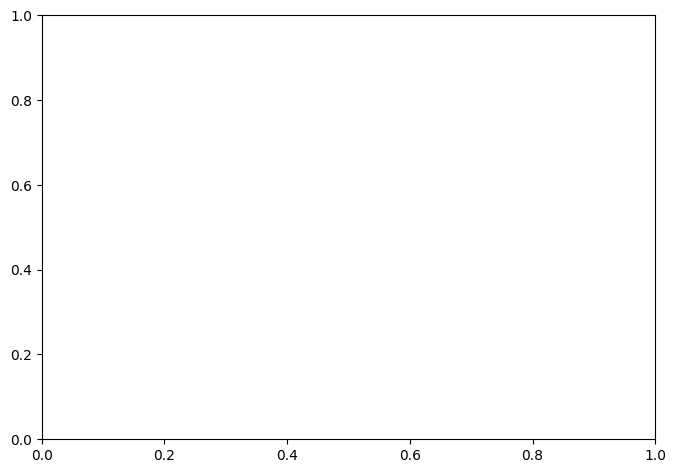

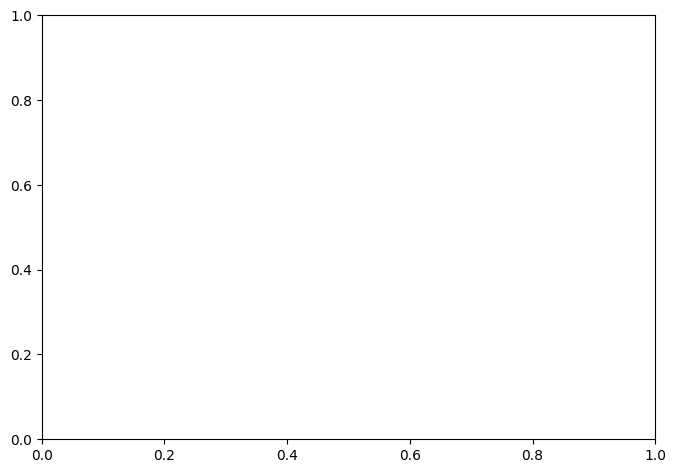

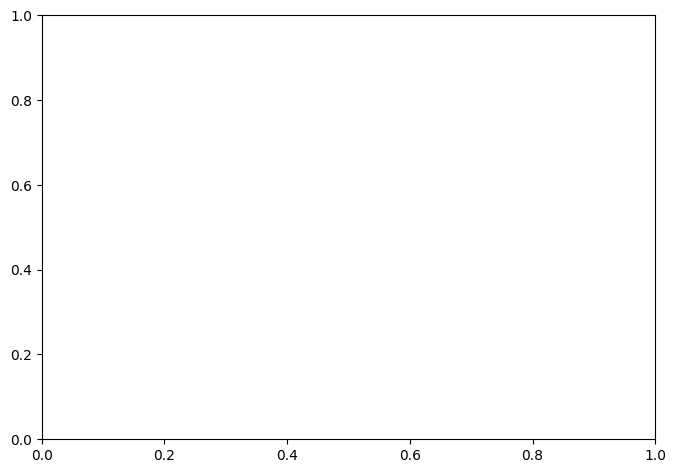

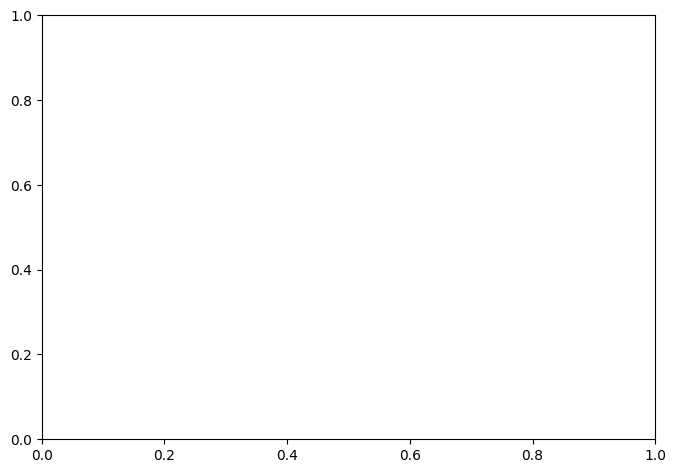

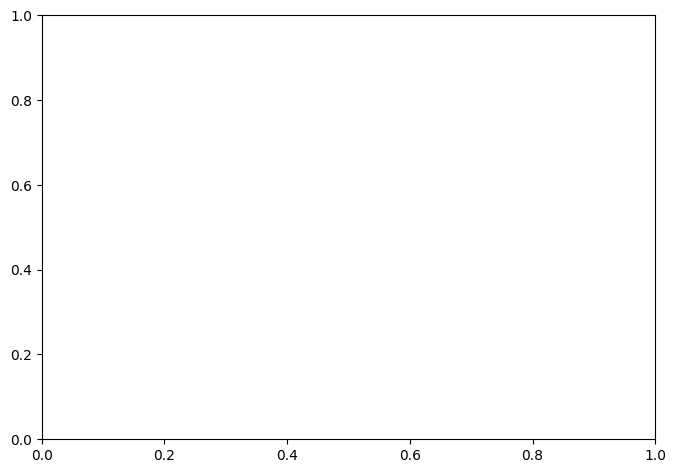

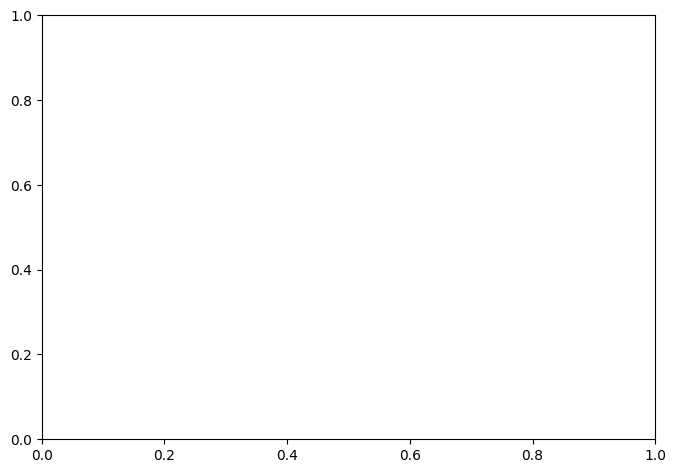

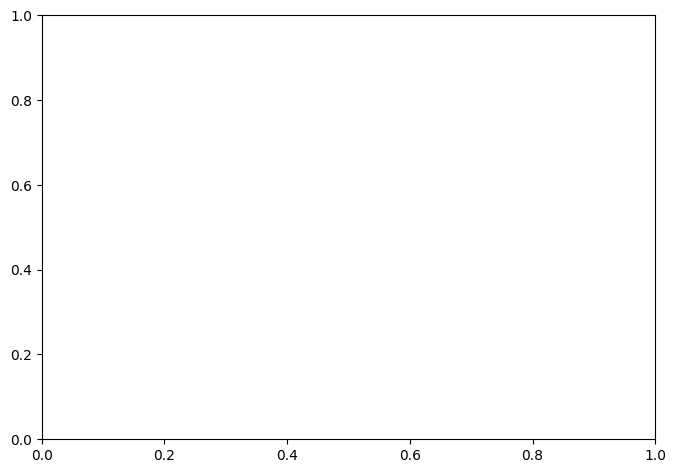

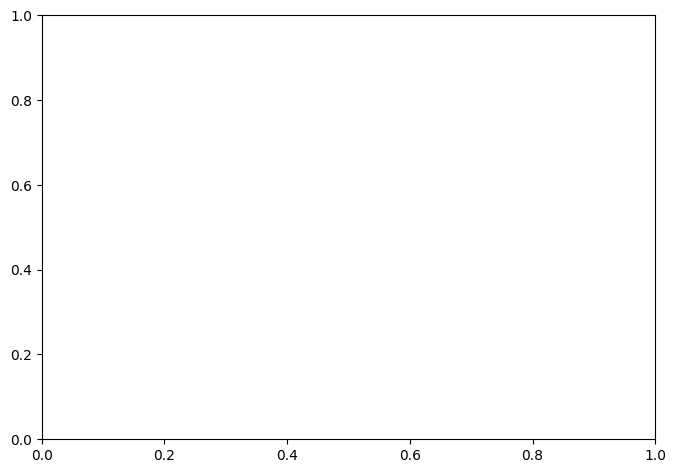

In [22]:
import openpyxl
import clusterization
importlib.reload(clusterization)
importlib.reload(sklearn)

import numpy as np

import sklearn
import hdbscan

from importlib.metadata import version

print(version("hdbscan"))
print(sklearn.__version__)

filename = './model_report.xlsx'

wb = openpyxl.Workbook()
wb.create_sheet('ModelReport')
ws = wb['ModelReport']

ws.append(['Model', 'Scaling','PCA','t-SNE','TruncatedSVD', 'Number of variables','Hyperparams', 'Inertia', 'Silhouette', 'Silhouette Increase from base model %', 'Silhouette for test data', 'Silhouette for test data increase %','Scatter plot train', 'Dendrogram', 'Scatter plot test', 'PCA variance', 'Cross-Tabulation'])

X = df.drop(columns=['city_name'])

clusterization.base_model(X, ws)

model_options = [
    'agglomerative',
    'dbscan'
]

data_preprocessing = [
        {'scaling':False,
         'pca':False,
         'tsne': False,
         'truncatedsvd':False},

        {'scaling':False,
         'pca':True,
         'tsne': False,
         'truncatedsvd':False},

        {'scaling':True,
         'pca':True,
         'tsne': False,
         'truncatedsvd':False},

        {'scaling':False,
         'pca':False,
         'tsne': False,
         'truncatedsvd':True},

        {'scaling':True,
         'pca':False,
         'tsne': False,
         'truncatedsvd':True},
    ]

n_components = np.append(np.arange(1, min(X.columns.size, 10), 1), X.columns.size)
print(f'{n_components=}')

for name in model_options:
    for preprocessing in data_preprocessing:
        for n_component in n_components:
            scaling = preprocessing['scaling']
            pca = preprocessing['pca']
            tsne = preprocessing['tsne']
            truncatedsvd = preprocessing['truncatedsvd']
            
            clusterization.clusterize(X=X, name=name, n_features=n_component, scaling=scaling, pca=pca, tsne=tsne, truncatedsvd=truncatedsvd, ws=ws, clusterization_distance=30)

wb.save(filename)